# $\nu_e$ CC Inclusive — Systematics

Loads pre-saved `sel_topo` and the mcnu weights file.  
**Outputs:** `saved_syst/` (NPZ) · `plots_syst/` (PNG)

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os, sys, gc, warnings
import numpy as np
import pandas as pd
# import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

CAFPYANA_WD = '/home/castalyf/cafpyana'
for p in [CAFPYANA_WD, CAFPYANA_WD + '/pyanalib']:
    if p not in sys.path:
        sys.path.insert(0, p)

from analysis_village.unfolding.covariance import (
    get_covariance_matrix_self, get_covariance_matrix)
from analysis_village.unfolding.utils import plot_univ_hists, plot_heatmap

# ── Paths ──────────────────────────────────────────────────────────────────────
DF_OUT_DIR   = './nuecc_dfs'
SYST_DIR     = './saved_syst'
PLOT_DIR     = './plots_syst'
TARGET_POT   = 6.6e20
TITLE        = r'SBND $\nu_e$ CC Inclusive'
POT_LABEL    = r'$6.6\times10^{20}$ POT'

# sel_qual: the ONLY file needed for all analysis (POT, events, truth)
SEL_FILE = f'{DF_OUT_DIR}/selected_nuecc_qual.df'

# DF_FILE: ONLY used in Cell 3 (mct_index for weight alignment).
# MUST be the same file used when sel_qual was generated.
# DF_FILE      = '/home/castalyf/cafpyana_out/mc1e20_nueCC_test_small.df'
DF_FILE      = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_v2.df'


# WEIGHTS_FILE: universe weights (flux/GENIE reweighting)
# WEIGHTS_FILE = '/home/castalyf/cafpyana_out/mc1e20_nueCC_sys_test_small.df'
WEIGHTS_FILE = '/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/mc1e20_nueCC_sys_v2.df'

for d in [SYST_DIR, PLOT_DIR,
          f'{PLOT_DIR}/univ', f'{PLOT_DIR}/cov', f'{PLOT_DIR}/fracunc']:
    os.makedirs(d, exist_ok=True)
print('Paths OK')


Paths OK


In [2]:
def _load_hdf_key(hdf_file, key_prefix):
    with pd.HDFStore(hdf_file, mode="r") as store:
        keys = store.keys()

        # /split may exist as a raw PyTables node (not a pandas DataFrame),
        # so guard the read — don't just check membership.
        if '/split' in keys:
            try:
                split_df = store['split']
                n = int(split_df['n_split'].iloc[0])
                return pd.concat([store[f'{key_prefix}_{k}'] for k in range(n)])
            except (AttributeError, KeyError, TypeError):
                pass   # fall through to prefix-matching below

        matching = sorted(
            k for k in keys
            if k.lstrip('/').startswith(key_prefix.lstrip('/'))
        )
        if not matching:
            raise KeyError(f"No keys matching {key_prefix!r} in {hdf_file}")
        return pd.concat([store[k] for k in matching])

histpotdf = _load_hdf_key(DF_FILE, 'histpotdf')
# statsdf   = _load_hdf_key(DF_FILE, 'stats')
statsdf   = _load_hdf_key(DF_FILE, 'truth_info')

# ── Load sel_qual (the only file we need for syst analysis) ───────────────────
sel_topo = pd.read_hdf(SEL_FILE)

# Deduplicate safety guard
if sel_topo.index.duplicated().any():
    print(f'WARNING: {sel_topo.index.duplicated().sum()} duplicate rows — deduplicating')
    sel_topo = sel_topo[~sel_topo.index.duplicated(keep='first')]

print(f'sel_topo shape : {sel_topo.shape}')
print(f'sel_topo cols  : {list(sel_topo.columns)}')

# ── pot_scale: read from sel_qual — avoids any DF_FILE mismatch ───────────────
pot_scale = float(sel_topo['pot_scale'].iloc[0])

# ── n_true_signal: all is_sig==True rows (presel denominator) ─────────────────
n_true_signal = int(sel_topo['is_sig'].sum())

# ── TARGET_POT back-computed so labels are consistent ─────────────────────────
# (sel_qual stores pot_scale = TARGET_POT / sample_POT, so we use stored value)
print(f'\npot_scale     : {pot_scale:.4f}')
print(f'n_true_signal : {n_true_signal:,}  (signal in presel — efficiency denominator)')

# Quick sanity check: signal at each stage
for col in [c for c in sel_topo.columns if c.startswith('sel_')]:
    n_sig = int((sel_topo[col] & sel_topo['is_sig']).sum())
    n_tot = int(sel_topo[col].sum())
    print(f'  {col:<35} sig={n_sig:>6,}  total={n_tot:>9,}  '
          f'weighted_sig={n_sig*pot_scale:.1f}')


sel_topo shape : (980816, 16)
sel_topo cols  : ['truth_cat', 'is_sig', 'reco_ke', 'reco_costheta', 'reco_p', 'true_ke', 'true_costheta', 'true_p', 'sel_precut', 'sel_valid_flashmatch', 'sel_fiducial', 'sel_single_electron', 'sel_electron_primary_score', 'sel_electron_pid_score', 'sel_vertex_distance', 'pot_scale']

pot_scale     : 4.3862
n_true_signal : 3,835  (signal in presel — efficiency denominator)
  sel_precut                          sig= 3,835  total=  980,816  weighted_sig=16821.0
  sel_valid_flashmatch                sig= 3,835  total=  980,816  weighted_sig=16821.0
  sel_fiducial                        sig= 3,835  total=  980,816  weighted_sig=16821.0
  sel_single_electron                 sig= 3,597  total=   28,494  weighted_sig=15777.1
  sel_electron_primary_score          sig= 3,053  total=   15,278  weighted_sig=13391.0
  sel_electron_pid_score              sig= 2,453  total=    4,402  weighted_sig=10759.3
  sel_vertex_distance                 sig= 2,305  total=    3,730

In [3]:
sel_topo.to_pickle('./nuecc_dfs/selected_nuecc_qual.pkl')
print(f"Saved pickle: {sel_topo.shape}")

Saved pickle: (980816, 16)


## 2.Load Weights & Universe Columns

In [4]:
mcnu_df = _load_hdf_key(WEIGHTS_FILE, 'mcnu')
print(f'mcnu_df shape : {mcnu_df.shape}')
print(f'mcnu_df index : {mcnu_df.index.names}')

def _is_univ(c):
    return isinstance(c, tuple) and any('univ' in str(p).lower() for p in c)
def _matches(c, kws):
    return isinstance(c, tuple) and any(
        any(kw in str(p).lower() for kw in kws) for p in c)

all_cols   = list(mcnu_df.columns)
bnb_cols   = [c for c in all_cols if _is_univ(c) and _matches(c,
              ['flux','bnb','beam','expskin','horncurrent','kplus','kminus',
               'kzero','piplus','piminus','nucleon','pion'])]
genie_cols = [c for c in all_cols if _is_univ(c) and _matches(c, ['genie','xsr','knob'])]
extra_cols = [c for c in all_cols if _is_univ(c) and _matches(c, ['extra_xsec'])]

if not bnb_cols:
    bnb_cols   = [c for c in all_cols if _is_univ(c) and _matches(c, ['flux'])]
if not genie_cols:
    genie_cols = [c for c in all_cols if _is_univ(c) and _matches(c, ['genie'])]

print(f'BNB cols  : {len(bnb_cols)}')
print(f'GENIE cols: {len(genie_cols)}')
print(f'Extra xsec cols: {len(extra_cols)}')


# Extract weight columns immediately, then free the full mcnu_df


mcnu_df shape : (938900, 300)
mcnu_df index : ['__ntuple', 'entry', 'rec.mc.nu..index']
BNB cols  : 100
GENIE cols: 100
Extra xsec cols: 100


## 3. Align Weights to sel_topo

Reads **only** the `mct_index` column from `evtdf` (chunked). Frees everything temporary afterwards.

In [5]:

print('Reading mct_index column from evtdf ...')
with pd.HDFStore(DF_FILE, mode='r') as store:
    keys = store.keys()
    if '/split' in keys:
        n = int(store['split']['n_split'].iloc[0])
        evt_keys = [f'/evt_{k}' for k in range(n)]
    else:
        evt_keys = sorted(k for k in keys if k.lstrip('/').startswith('evt'))

with pd.HDFStore(DF_FILE, mode='r') as store:
    sample_cols = store[evt_keys[0]].columns.tolist()

mct_col = next((c for c in sample_cols
                if 'mct_index' in str(c) and 'dlp_true' in str(c)), None)
if mct_col is None:
    mct_col = next((c for c in sample_cols if 'mct_index' in str(c)), None)
print(f'mct_index column: {mct_col}')

mct_frames = []
for ek in tqdm(evt_keys, desc='chunks'):
    with pd.HDFStore(DF_FILE, mode='r') as store:
        chunk = store[ek][[mct_col]]
    il = chunk.index.names[:-1] if chunk.index.nlevels > 1 else chunk.index.names
    mct_frames.append(chunk.groupby(level=il).first()); del chunk
mct_inter = pd.concat(mct_frames); del mct_frames; gc.collect()
print(f'mct_inter shape: {mct_inter.shape}')

# Merge with mcnu weights
wgt_cols  = bnb_cols + genie_cols + extra_cols
mcnu_sub  = mcnu_df[wgt_cols].copy() if wgt_cols else pd.DataFrame(index=mcnu_df.index)
del mcnu_df; gc.collect()

mcnu_idx   = mcnu_sub.index.names
inter_idx  = list(mct_inter.index.names)
mct_r  = mct_inter.reset_index()
mcnu_r = mcnu_sub.reset_index()

# ── Flatten MultiIndex columns to plain strings before merging ─────────────────
def _flat(cols):
    return ['|'.join(str(p) for p in c).strip('|') if isinstance(c, tuple) else str(c)
            for c in cols]

mct_r.columns  = _flat(mct_r.columns)
mcnu_r.columns = _flat(mcnu_r.columns)
print(f'mcnu_sub shape: {mcnu_sub.shape}')

# Re-derive key names after flattening
inter_idx_flat = _flat(inter_idx)      # ['__ntuple', 'entry', 'rec.dlp..index']
mcnu_idx_flat  = _flat(mcnu_idx)       # ['__ntuple', 'entry', 'rec.mc.nu..index']
mct_col_flat   = _flat([mct_col])[0]   # 'rec|dlp_true|mct_index||'
wgt_cols_flat  = _flat(wgt_cols)

merged = mct_r.merge(
    mcnu_r,
    left_on  = [inter_idx_flat[0], inter_idx_flat[1], mct_col_flat],
    right_on = [mcnu_idx_flat[0],  mcnu_idx_flat[1],  mcnu_idx_flat[2]],
    how='left',
)
merged = merged.set_index(inter_idx_flat)

# Restore original tuple column names so downstream cells are unaffected
wgt_aligned = merged[wgt_cols_flat].copy()
wgt_aligned.columns    = wgt_cols   # put tuple cols back
wgt_aligned.index.names = inter_idx  # restore original index names

del mct_r, mcnu_r, merged, mct_inter, mcnu_sub; gc.collect()

bnb_cols_aligned   = [c for c in wgt_aligned.columns if c in set(bnb_cols)]
genie_cols_aligned = [c for c in wgt_aligned.columns if c in set(genie_cols)]
extra_cols_aligned = [c for c in wgt_aligned.columns if c in set(extra_cols)]
print(f'wgt_aligned: {wgt_aligned.shape}  BNB={len(bnb_cols_aligned)}  '
      f'GENIE={len(genie_cols_aligned)}  Extra={len(extra_cols_aligned)}')


Reading mct_index column from evtdf ...
mct_index column: ('rec', 'dlp_true', 'mct_index', '', '')


chunks:   0%|          | 0/1 [00:00<?, ?it/s]

mct_inter shape: (980816, 1)
mcnu_sub shape: (938900, 300)
wgt_aligned: (980816, 300)  BNB=100  GENIE=100  Extra=100


## 4. Binning & Variable Configs

In [6]:
RECO_BINS   = np.linspace(0, 2000, 8)
TRUE_BINS   = np.linspace(0, 2000, 8)
COS_BINS    = np.linspace(-1, 1, 11)
FINAL_STAGE = 'sel_vertex_distance'   # or 'sel_single_electron' for qual cuts

class VarConfig:
    def __init__(self, name, bins, xlabel):
        self.name          = name
        self.bins          = bins
        self.bin_centers   = 0.5 * (bins[:-1] + bins[1:])
        self.var_plot_name = xlabel
        self.var_labels    = [xlabel, xlabel, xlabel.replace('Reco','True')]
        self.pot_label     = POT_LABEL

VAR_CFGS = [
    VarConfig('reco_ke',       RECO_BINS, r'Reco leading-$e^-$ KE [MeV]'),
    VarConfig('reco_costheta', COS_BINS,  r'Reco leading-$e^-$ $\cos\theta$'),
]
print('VarConfigs ready:')
for v in VAR_CFGS:
    print(f'  {v.name}  n_bins={len(v.bins)-1}')


VarConfigs ready:
  reco_ke  n_bins=7
  reco_costheta  n_bins=10


In [7]:
for c in genie_cols[:5]:
    print(
        c,
        wgt_aligned[c].mean(),
        wgt_aligned[c].std()
    )

('GENIE', 'univ_0') 1.0505156534096853 0.9714003069809386
('GENIE', 'univ_1') 1.0384126935971236 0.9997330888561109
('GENIE', 'univ_2') 1.0457860847566125 0.9661077568930794
('GENIE', 'univ_3') 1.0352441211579821 0.9858591283423668
('GENIE', 'univ_4') 1.0489755302625057 1.013981677292823


In [8]:
from scipy.stats import chi2 as chi2_dist

def chi2_text(obs, exp, cov, label=""):
    """Return a string 'χ²/ndof = X.X/N (p = 0.XX)' for plot annotation."""
    diff = obs - exp
    try:
        cov_inv = np.linalg.inv(cov)
    except np.linalg.LinAlgError:
        cov_inv = np.linalg.pinv(cov)
    chi2_val = float(diff @ cov_inv @ diff)
    ndof = len(diff)
    pval = 1.0 - chi2_dist.cdf(chi2_val, ndof)
    return f"{label}$\\chi^2$/ndof = {chi2_val:.1f}/{ndof} (p = {pval:.2f})"

## 5. CV Histograms & Response Matrix

In [9]:
_eps = 1e-8

def build_cv(sel_df, stage_col, var_col, bins, ps,
             true_col=None, true_bins=None):
    sel  = sel_df[sel_df[stage_col]]
    smk  = (sel['truth_cat'] == 0).values
    bmk  = sel['truth_cat'].between(1, 6).values
    reco = sel[var_col].clip(bins[0], bins[-1] - _eps).values
    w    = np.full(len(sel), ps)
    sig_cv, _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
    bkg_cv, _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])
    out = dict(sig_cv=sig_cv, bkg_cv=bkg_cv)
    if true_col and true_bins is not None:
        tv = sel.loc[smk, true_col].dropna()
        true_cv, _ = np.histogram(
            tv.clip(true_bins[0], true_bins[-1] - _eps),
            bins=true_bins, weights=np.full(len(tv), ps))
        valid = smk & sel[var_col].notna().values & sel[true_col].notna().values
        r2d, _, _ = np.histogram2d(
            sel.loc[valid, true_col].clip(true_bins[0], true_bins[-1] - _eps),
            sel.loc[valid, var_col].clip(bins[0], bins[-1] - _eps),
            bins=[true_bins, bins])
        out['true_sig_cv'] = true_cv
        out['response']    = r2d / r2d.sum(axis=1, keepdims=True).clip(1)
    return out

cv_results = {}
for vcfg in VAR_CFGS:
    tc = 'true_ke' if vcfg.name == 'reco_ke' else 'true_costheta'
    tb = TRUE_BINS if vcfg.name == 'reco_ke'  else vcfg.bins
    cv_results[vcfg.name] = build_cv(
        sel_topo, FINAL_STAGE, vcfg.name, vcfg.bins, pot_scale, tc, tb)
    cv = cv_results[vcfg.name]
    print(f'{vcfg.name}: sig={cv["sig_cv"].sum():.1f}  bkg={cv["bkg_cv"].sum():.1f}')
print('CV done.')


reco_ke: sig=10110.1  bkg=4285.3
reco_costheta: sig=10110.1  bkg=4285.3
CV done.


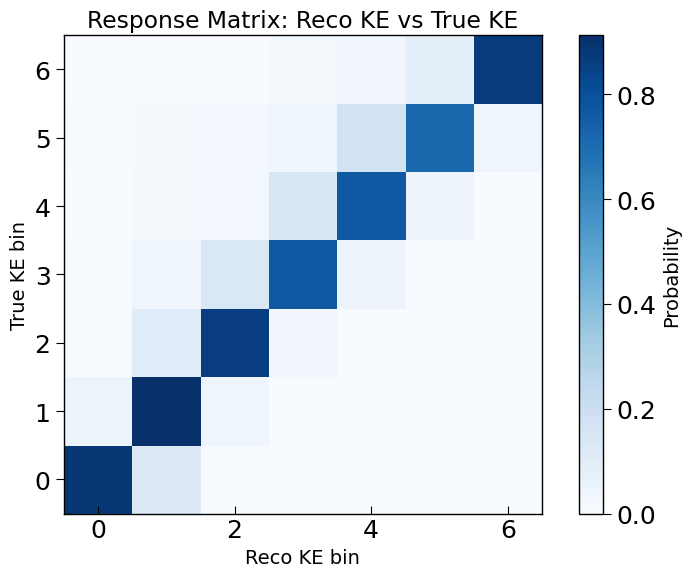

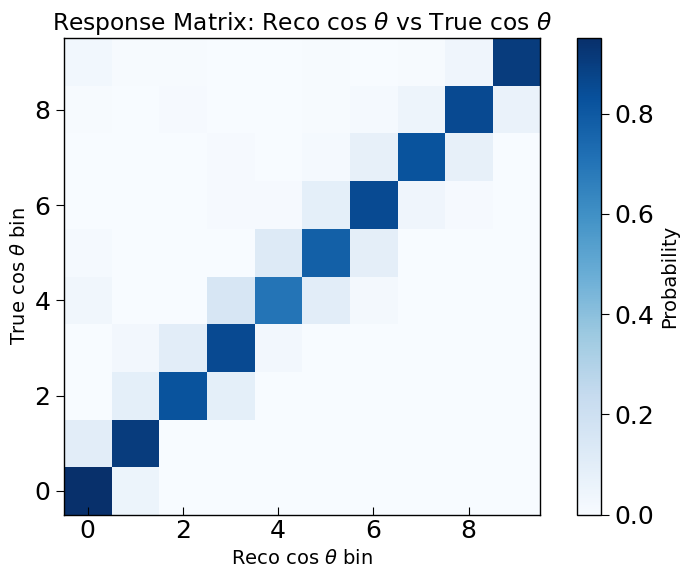

In [10]:
R = cv_results['reco_ke']['response']
plt.imshow(R,
           origin='lower',
           cmap='Blues')
plt.xlabel('Reco KE bin')
plt.ylabel('True KE bin')
plt.title('Response Matrix: Reco KE vs True KE')
plt.colorbar(label='Probability')
plt.tight_layout()
fig = os.path.join(PLOT_DIR, 'response_matrix_reco_ke.png')
plt.savefig(fig, dpi=300, bbox_inches='tight')
plt.show()

R = cv_results['reco_costheta']['response']
plt.imshow(R,
           origin='lower',
           cmap='Blues')
plt.xlabel(r'Reco cos $\theta$ bin')
plt.ylabel(r'True cos $\theta$ bin')
plt.title(r'Response Matrix: Reco cos $\theta$ vs True cos $\theta$')
plt.colorbar(label='Probability')
plt.tight_layout()
fig = os.path.join(PLOT_DIR, 'response_matrix_reco_costheta.png')
plt.savefig(fig, dpi=300, bbox_inches='tight')
plt.show()

In [11]:
for v in ['reco_ke','reco_costheta']:
    R = cv_results[v]['response']

    print(v)
    print(R.shape)
    print("diag =", np.diag(R))
    print("mean =", np.mean(np.diag(R)))

reco_ke
(7, 7)
diag = [0.8852459  0.91237113 0.85941043 0.768      0.76706827 0.71657754
 0.87106017]
mean = 0.8256762073740082
reco_costheta
(10, 10)
diag = [0.95       0.90322581 0.82352941 0.85365854 0.7        0.77272727
 0.8503937  0.82191781 0.85714286 0.90513834]
mean = 0.8437733733599343


In [12]:
import uproot
from makedf.getsyst import print_syst_all

f = uproot.open("/exp/sbnd/data/users/castalyf/nue_sel/production_files/gen1/input598.caf.root")
print_syst_all(f)

Index: 0   | Name: GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE                   | Type: 3     | Univ: 6
Index: 1   | Name: GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE                   | Type: 3     | Univ: 6
Index: 2   | Name: GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE                   | Type: 3     | Univ: 6
Index: 3   | Name: GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE                   | Type: 3     | Univ: 6
Index: 4   | Name: GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape               | Type: 3     | Univ: 1
Index: 5   | Name: GENIEReWeight_SBN_v1_multisigma_RPA_CCQE                     | Type: 3     | Univ: 6
Index: 6   | Name: GENIEReWeight_SBN_v1_multisigma_CoulombCCQE                  | Type: 3     | Univ: 6
Index: 7   | Name: GENIEReWeight_SBN_v1_multisigma_NormCCMEC                    | Type: 3     | Univ: 6
Index: 8   | Name: GENIEReWeight_SBN_v1_multisigma_NormNCMEC                    | Type: 3     | Univ: 6
Index: 9   | Name: GENIEReWeight_SBN_v1_multisigma_DecayAngMEC  

## 6. Universe Histograms (Flux & GENIE)

In [13]:

# def build_univ_hists(sel_df, stage_col, wgt_aligned, univ_cols,
#                      var_col, bins, ps, clip=10.0):
#     sel  = sel_df[sel_df[stage_col]]
#     smk  = (sel['truth_cat'] == 0).values
#     bmk  = sel['truth_cat'].between(1, 6).values
#     reco = sel[var_col].clip(bins[0], bins[-1] - 1e-8).values
#     nwl  = wgt_aligned.index.nlevels
#     sidx = (sel.index.droplevel(list(range(nwl, sel.index.nlevels)))
#             if sel.index.nlevels > nwl else sel.index)
#     wmat = wgt_aligned[univ_cols].reindex(sidx).values.astype(np.float32)
#     nu   = len(univ_cols); nb = len(bins) - 1
#     su   = np.zeros((nu, nb)); bu = np.zeros((nu, nb))
#     for ui in tqdm(range(nu), desc=var_col, leave=False):
#         w = np.where(np.isfinite(wmat[:, ui]), wmat[:, ui].astype(float), 1.0)
#         w = np.clip(w, 0.0, clip) * ps
#         su[ui], _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
#         bu[ui], _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])
#     return su, bu


In [14]:
def build_univ_hists(sel_df, stage_col, wgt_aligned, univ_cols,
                     var_col, bins, ps, clip=10.0):
    sel  = sel_df[sel_df[stage_col]]
    if sel.empty:
        nb = len(bins) - 1; nu = len(univ_cols)
        return np.zeros((nu, nb)), np.zeros((nu, nb))

    smk  = (sel['truth_cat'] == 0).values
    bmk  = sel['truth_cat'].between(1, 6).values
    reco = sel[var_col].clip(bins[0], bins[-1] - 1e-8).values

    # ── align sel index levels to wgt_aligned index levels ───────────────────
    nwl = wgt_aligned.index.nlevels
    if sel.index.nlevels > nwl:
        sidx = sel.index.droplevel(list(range(nwl, sel.index.nlevels)))
    elif sel.index.nlevels == nwl:
        sidx = sel.index
    else:
        # sel has FEWER levels than wgt — unexpected; fall back to unweighted
        warnings.warn(
            f"build_univ_hists: sel has {sel.index.nlevels} index levels but "
            f"wgt_aligned has {nwl}. Returning unit weights."
        )
        nb = len(bins) - 1; nu = len(univ_cols)
        return np.zeros((nu, nb)), np.zeros((nu, nb))

    # Add this at the TOP of build_univ_hists, right after computing sidx:
    print(f"  sel index nlevels: {sel.index.nlevels}, names: {sel.index.names}")
    print(f"  wgt index nlevels: {wgt_aligned.index.nlevels}, names: {wgt_aligned.index.names}")
    print(f"  sidx nlevels: {sidx.nlevels}, names: {sidx.names}")
    print(f"  sel first 3 indices:  {list(sel.index[:3])}")
    print(f"  sidx first 3 indices: {list(sidx[:3])}")
    print(f"  wgt first 3 indices:  {list(wgt_aligned.index[:3])}")
    
    # Check overlap
    overlap = sidx.isin(wgt_aligned.index)
    print(f"  sidx ∩ wgt_aligned: {overlap.sum()} / {len(sidx)} "
          f"({overlap.mean()*100:.1f}%)")
    
    # ── guard against duplicate wgt_aligned index (merged files) ─────────────
    wgt_sub = wgt_aligned[univ_cols]
    if wgt_sub.index.duplicated().any():
        wgt_sub = wgt_sub[~wgt_sub.index.duplicated(keep='first')]

    # reindex: rows in sel that have no weight match get NaN → replaced by 1.0
    wmat = wgt_sub.reindex(sidx).values.astype(np.float32)

    # sanity: warn if most weights are missing (likely file mismatch)
    nan_frac = np.isnan(wmat).mean()
    if nan_frac > 0.5:
        warnings.warn(
            f"build_univ_hists [{var_col}]: {nan_frac*100:.0f}% of weights "
            "are NaN after reindex — check that DF_FILE and WEIGHTS_FILE "
            "correspond to the same MC sample."
        )

    nu = len(univ_cols); nb = len(bins) - 1
    su = np.zeros((nu, nb)); bu = np.zeros((nu, nb))

    for ui in tqdm(range(nu), desc=var_col, leave=False):
        w = np.where(np.isfinite(wmat[:, ui]), wmat[:, ui].astype(float), 1.0)
        w = np.clip(w, 0.0, clip) * ps
        su[ui], _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
        bu[ui], _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])

    return su, bu

In [15]:
SRC_LABEL = {'flux': 'BNB Flux', 'genie': 'GENIE', 'extra_xsec': 'Other Xsec Syst.', 'mcstat': 'MCstat'}
univ_results = {}

for vcfg in VAR_CFGS:
    univ_results[vcfg.name] = {}
    if bnb_cols_aligned:
        print(f'[{vcfg.name}] BNB ...')
        su, bu = build_univ_hists(sel_topo, FINAL_STAGE, wgt_aligned,
                                  bnb_cols_aligned, vcfg.name, vcfg.bins, pot_scale)
        univ_results[vcfg.name]['flux'] = {'sig': su, 'bkg': bu}
    if genie_cols_aligned:
        print(f'[{vcfg.name}] GENIE ...')
        su, bu = build_univ_hists(sel_topo, FINAL_STAGE, wgt_aligned,
                                  genie_cols_aligned, vcfg.name, vcfg.bins, pot_scale)
        univ_results[vcfg.name]['genie'] = {'sig': su, 'bkg': bu}
    # ── NEW: extra xsec (MINERvA, MiscInteraction, NOvA) ──────────────────
    if extra_cols_aligned:
        print(f'[{vcfg.name}] Extra xsec ...')
        su, bu = build_univ_hists(sel_topo, FINAL_STAGE, wgt_aligned,
                                  extra_cols_aligned, vcfg.name, vcfg.bins, pot_scale)
        univ_results[vcfg.name]['extra_xsec'] = {'sig': su, 'bkg': bu}
    gc.collect()
print('Flux/GENIE/Extra xsec universes done.')

[reco_ke] BNB ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  sidx first 3 indices: [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  wgt first 3 indices:  [(0, 2, 0), (0, 3, 6), (0, 4, 12)]
  sidx ∩ wgt_aligned: 3730 / 3730 (100.0%)


reco_ke:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_ke] GENIE ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  sidx first 3 indices: [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  wgt first 3 indices:  [(0, 2, 0), (0, 3, 6), (0, 4, 12)]
  sidx ∩ wgt_aligned: 3730 / 3730 (100.0%)


reco_ke:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_ke] Extra xsec ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  sidx first 3 indices: [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  wgt first 3 indices:  [(0, 2, 0), (0, 3, 6), (0, 4, 12)]
  sidx ∩ wgt_aligned: 3730 / 3730 (100.0%)


...

[reco_costheta] GENIE ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  sidx first 3 indices: [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  wgt first 3 indices:  [(0, 2, 0), (0, 3, 6), (0, 4, 12)]
  sidx ∩ wgt_aligned: 3730 / 3730 (100.0%)


reco_costheta:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_costheta] Extra xsec ...
  sel index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  wgt index nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sidx nlevels: 3, names: ['__ntuple', 'entry', 'rec.dlp..index']
  sel first 3 indices:  [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  sidx first 3 indices: [(0, 1250, 6), (0, 1388, 4), (0, 2607, 1)]
  wgt first 3 indices:  [(0, 2, 0), (0, 3, 6), (0, 4, 12)]
  sidx ∩ wgt_aligned: 3730 / 3730 (100.0%)


reco_costheta:   0%|          | 0/100 [00:00<?, ?it/s]

Flux/GENIE/Extra xsec universes done.


## 7. MCstat Universes (Poisson resampling)

In [16]:

from numpy.random import Generator, PCG64, SeedSequence

def build_mcstat_univs(sel_df, stage_col, var_col, bins, ps, nu=100, seed=42):
    sel  = sel_df[sel_df[stage_col]]
    smk  = (sel['truth_cat'] == 0).values
    bmk  = sel['truth_cat'].between(1, 6).values
    reco = sel[var_col].clip(bins[0], bins[-1] - 1e-8).values
    ne   = len(sel); ss = SeedSequence(seed); kids = ss.spawn(nu)
    nb   = len(bins) - 1; su = np.zeros((nu, nb)); bu = np.zeros((nu, nb))
    for u in tqdm(range(nu), desc=f'{var_col} MCstat', leave=False):
        w = Generator(PCG64(kids[u])).poisson(1.0, size=ne) * ps
        su[u], _ = np.histogram(reco[smk], bins=bins, weights=w[smk])
        bu[u], _ = np.histogram(reco[bmk], bins=bins, weights=w[bmk])
    return su, bu

for vcfg in VAR_CFGS:
    print(f'[{vcfg.name}] MCstat ...')
    su, bu = build_mcstat_univs(sel_topo, FINAL_STAGE, vcfg.name, vcfg.bins, pot_scale)
    univ_results[vcfg.name]['mcstat'] = {'sig': su, 'bkg': bu}

del wgt_aligned, bnb_cols_aligned, genie_cols_aligned; gc.collect()
print('MCstat done. Weights freed.')


[reco_ke] MCstat ...


reco_ke MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

[reco_costheta] MCstat ...


reco_costheta MCstat:   0%|          | 0/100 [00:00<?, ?it/s]

MCstat done. Weights freed.


## 8. Covariance Matrices

In [17]:

def _mat(block):
    return block.get('cov', block) if isinstance(block, dict) else block

def compute_covs(su, bu, s_cv, b_cv):
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', RuntimeWarning)
        return {
            'cov_ms_ms': get_covariance_matrix_self(su, s_cv),
            'cov_bs_bs': get_covariance_matrix_self(bu, b_cv),
            'cov_ms_bs': get_covariance_matrix(su, s_cv, bu, b_cv),
            'cov_bs_ms': get_covariance_matrix(bu, b_cv, su, s_cv),
        }

cov_results = {}
for vcfg in VAR_CFGS:
    cov_results[vcfg.name] = {}
    cv = cv_results[vcfg.name]
    for src, ud in univ_results[vcfg.name].items():
        print(f'[{vcfg.name}] cov: {src} ...')
        cov_results[vcfg.name][src] = compute_covs(
            ud['sig'], ud['bkg'], cv['sig_cv'], cv['bkg_cv'])
print('All covariances computed.')


[reco_ke] cov: flux ...
[reco_ke] cov: genie ...
[reco_ke] cov: extra_xsec ...
[reco_ke] cov: mcstat ...
[reco_costheta] cov: flux ...
[reco_costheta] cov: genie ...
[reco_costheta] cov: extra_xsec ...
[reco_costheta] cov: mcstat ...
All covariances computed.


In [18]:
# ── N_targets calculation from your FV definition ────────────────────────────
# FV from _fiducial_cut_tmp in make_nueCC_df.py:
#   |x| in (5, 190), combined z/y regions

# Region 1: z in (10,250), y in (-190,190), full x  
V1 = (2 * 185.0) * 380.0 * 240.0   # cm³

# Region 2: z in (250,450), y in (-190,100), x < 0 only
V2 = 185.0 * 290.0 * 200.0         # cm³

# Region 3: z in (250,450), y in (-190,190), x > 0 only
V3 = 185.0 * 380.0 * 200.0         # cm³

V_FV = V1 + V2 + V3
rho_LAr = 1.3954    # g/cm³  (SBND LAr density)
N_A     = 6.022e23  # Avogadro
A_Ar    = 39.948     # g/mol

M_FV = rho_LAr * V_FV
N_targets = M_FV * N_A / A_Ar
print(f"FV volume:  {V_FV:.2e} cm³")
print(f"LAr mass:   {M_FV:.2e} g = {M_FV/1e6:.3f} tonnes")
print(f"N_targets:  {N_targets:.4e}")

FRAC_POT      = 0.02    # 2% POT counting uncertainty
FRAC_NTARGETS = 0.01    # 1% fiducial mass / number of targets uncertainty

for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    sig_cv = cv['sig_cv']
    bkg_cv = cv['bkg_cv']

    for src_name, frac in [('pot', FRAC_POT), ('ntargets', FRAC_NTARGETS)]:
        cov_ms = frac**2 * np.outer(sig_cv, sig_cv)
        cov_bs = frac**2 * np.outer(bkg_cv, bkg_cv)

        cov_results[vcfg.name][src_name] = {
            'cov_ms_ms': cov_ms,
            'cov_bs_bs': cov_bs,
            'cov_ms_bs': frac**2 * np.outer(sig_cv, bkg_cv),
            'cov_bs_ms': frac**2 * np.outer(bkg_cv, sig_cv),
        }
        print(f'[{vcfg.name}] {src_name}: frac_unc={frac}, '
              f'diag sig = {np.sqrt(np.diag(cov_ms))}')

    # Also add to univ_results so the save/plot loop picks them up
    # (these don't have universe histograms, so we skip the universe plots)

print('POT + N_targets covariance matrices added.')


FV volume:  5.85e+07 cm³
LAr mass:   8.17e+07 g = 81.678 tonnes
N_targets:  1.2313e+30
[reco_ke] pot: frac_unc=0.02, diag sig = [12.45673338 53.77448987 40.52824522 30.70321608 22.28176252 15.17616109
 27.28200057]
[reco_ke] ntargets: frac_unc=0.01, diag sig = [ 6.22836669 26.88724494 20.26412261 15.35160804 11.14088126  7.58808054
 13.64100029]
[reco_costheta] pot: frac_unc=0.02, diag sig = [  5.52657889   3.7721094    3.7721094    4.73706762   5.00023805
   8.42145355  12.45673338  18.50965312  37.28247666 102.72418864]
[reco_costheta] ntargets: frac_unc=0.01, diag sig = [ 2.76328945  1.8860547   1.8860547   2.36853381  2.50011902  4.21072678
  6.22836669  9.25482656 18.64123833 51.36209432]
POT + N_targets covariance matrices added.


### 7.1 Export output for Omnifold

OmniFold events: 6,399
BNB universes:   (100, 7)
GENIE universes: (100, 7)
CV signal:       [ 622.83666897 2688.7244935  2026.41226101 1535.16080379 1114.08812618
  758.80805445 1364.10002851]

BNB: shape=(6399, 100)
  Univ 0: mean=1.0159, std=0.0054, range=[1.0101, 1.0262]
  All universes: mean range [0.8984, 1.2364]

GENIE: shape=(6399, 100)
  Univ 0: mean=1.0549, std=0.0445, range=[1.0039, 1.1490]
  All universes: mean range [0.9760, 1.0951]


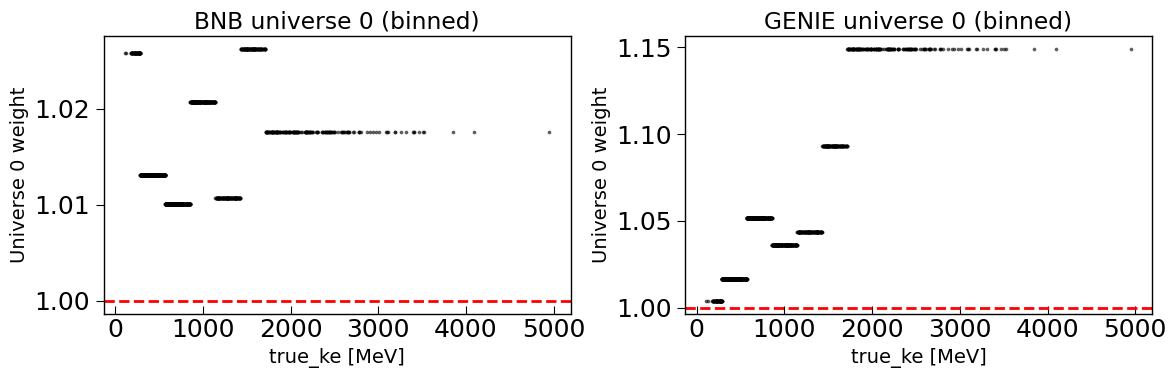

Done.


In [19]:
# ── Export binned fake data weights for OmniFold ─────────────────────────────
# Uses the already-computed universe histograms from build_univ_hists (cell 6),
# which handle the sel_topo ↔ wgt_aligned alignment internally.
# Per-event weights are assigned by bin: "binned fake data" (Roger-approved).
import numpy as np, os

OMNIFOLD_OUT = '/home/castalyf/Omnifold_SBND/sbnd/exported_weights/'
OMNIFOLD_DATA = '/home/castalyf/FormattedData_SBND/'
os.makedirs(OMNIFOLD_OUT, exist_ok=True)

# 1. Load the 6399 OmniFold events' truth and reco values (un-normalized)
truth_raw   = np.load(OMNIFOLD_DATA + 'mc_vals_truth_NoNorm.npy')  # (6399, 3)
mc_weights  = np.load(OMNIFOLD_DATA + 'mc_weights_reco.npy')       # (6399,)
true_ke     = truth_raw[:, 0]
n_events    = len(true_ke)
print(f"OmniFold events: {n_events:,}")

# 2. Get universe histograms from cell 6 output (already computed)
#    su shape: (N_universes, N_bins) — signal events per bin per universe
su_bnb   = univ_results['reco_ke']['flux']['sig']    # (100, 7)
su_genie = univ_results['reco_ke']['genie']['sig']   # (100, 7)
sig_cv   = cv_results['reco_ke']['sig_cv']           # (7,)

print(f"BNB universes:   {su_bnb.shape}")
print(f"GENIE universes: {su_genie.shape}")
print(f"CV signal:       {sig_cv}")

# 3. Per-bin ratio: universe / CV
#    Ratio > 1 = universe has more events than nominal; < 1 = fewer
ratio_bnb   = su_bnb   / np.clip(sig_cv[np.newaxis, :], 1.0, None)  # (100, 7)
ratio_genie = su_genie / np.clip(sig_cv[np.newaxis, :], 1.0, None)  # (100, 7)

# 4. Assign per-event weights by bin
#    Each event gets the ratio for the bin it falls in
bins_ke = np.linspace(0, 2000, 8)  # must match RECO_BINS from cell 4
bin_idx = np.digitize(true_ke.clip(bins_ke[0], bins_ke[-1] - 1e-8), bins_ke) - 1
bin_idx = np.clip(bin_idx, 0, len(bins_ke) - 2)

bnb_per_event   = np.ones((n_events, 100), dtype=np.float32)
genie_per_event = np.ones((n_events, 100), dtype=np.float32)

for u in range(100):
    bnb_per_event[:, u]   = ratio_bnb[u, bin_idx]
    genie_per_event[:, u] = ratio_genie[u, bin_idx]

# 5. Save
np.save(OMNIFOLD_OUT + 'bnb_universe_weights.npy',   bnb_per_event)
np.save(OMNIFOLD_OUT + 'genie_universe_weights.npy', genie_per_event)
np.save(OMNIFOLD_OUT + 'norm_uncertainties.npy',
        {'pot': FRAC_POT, 'ntargets': FRAC_NTARGETS})

# 6. Diagnostics
for name, vals in [('BNB', bnb_per_event), ('GENIE', genie_per_event)]:
    u0 = vals[:, 0]
    print(f"\n{name}: shape={vals.shape}")
    print(f"  Univ 0: mean={u0.mean():.4f}, std={u0.std():.4f}, "
          f"range=[{u0.min():.4f}, {u0.max():.4f}]")
    print(f"  All universes: mean range [{vals.mean(axis=0).min():.4f}, "
          f"{vals.mean(axis=0).max():.4f}]")

# 7. Quick plot: universe 0 weight vs true_ke
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name, vals in [(axes[0], 'BNB', bnb_per_event),
                        (axes[1], 'GENIE', genie_per_event)]:
    ax.scatter(true_ke[::5], vals[::5, 0], s=3, alpha=0.5)
    ax.axhline(1.0, color='r', linestyle='--')
    ax.set_xlabel('true_ke [MeV]')
    ax.set_ylabel('Universe 0 weight')
    ax.set_title(f'{name} universe 0 (binned)')
plt.tight_layout()
plt.savefig(OMNIFOLD_OUT + 'binned_fakedata_diagnostic.png', dpi=100)
plt.show()
print("Done.")

In [20]:
# ── Export MCstat universe weights for OmniFold ──────────────────────────────
from numpy.random import Generator, PCG64, SeedSequence

sig_sel = sel_topo[sel_topo['is_sig'] & sel_topo['sel_vertex_distance']].copy()
reco_raw = sig_sel[['reco_ke','reco_costheta','reco_p']].values.astype(np.float32)
valid = ~np.isnan(reco_raw).any(axis=1)
sig_sel = sig_sel[valid]
n = len(sig_sel)

n_univ = 100
seed = 42
ss = SeedSequence(seed)
kids = ss.spawn(n_univ)

mcstat_weights = np.zeros((n, n_univ), dtype=np.float32)
for u in range(n_univ):
    mcstat_weights[:, u] = Generator(PCG64(kids[u])).poisson(1.0, size=n).astype(np.float32)

np.save(OMNIFOLD_OUT + 'mcstat_universe_weights.npy', mcstat_weights)
print(f"MCstat saved: {mcstat_weights.shape}")
print(f"  Univ 0: mean={mcstat_weights[:,0].mean():.4f}, std={mcstat_weights[:,0].std():.4f}")

MCstat saved: (2305, 100)
  Univ 0: mean=0.9944, std=1.0013


## 9. Save NPZ Files

In [21]:

def save_npz(path, cv, covs, extra=None):
    p = dict(ms=cv['sig_cv'], bs=cv['bkg_cv'])
    if 'true_sig_cv' in cv: p['true_signal'] = cv['true_sig_cv']
    if 'response'    in cv: p['response']    = cv['response']
    for bk, bv in covs.items():
        if isinstance(bv, dict):
            for k, v in bv.items():
                if isinstance(v, np.ndarray): p[f'{bk}_{k}'] = v
        else:
            p[bk] = bv
    if extra: p.update(extra)
    np.savez(path, **p)
    print(f'  {os.path.basename(path)}  ({os.path.getsize(path)/1024:.0f} KB)')

for vcfg in VAR_CFGS:
    vd = os.path.join(SYST_DIR, vcfg.name); os.makedirs(vd, exist_ok=True)
    cv = cv_results[vcfg.name]
    for src, covs in cov_results[vcfg.name].items():
        save_npz(os.path.join(vd, f'{src}_cov_matrices.npz'), cv, covs)
        # In the total covariance computation, replace the existing sum:
    if len(cov_results[vcfg.name]) > 1:
        ts = sum(_mat(cov_results[vcfg.name][s]['cov_ms_ms'])
                 for s in cov_results[vcfg.name])
        tb = sum(_mat(cov_results[vcfg.name][s]['cov_bs_bs'])
                 for s in cov_results[vcfg.name])
        save_npz(os.path.join(vd, 'total_cov_matrices.npz'), cv, {},
                 extra=dict(total_cov_ms_ms=ts, total_cov_bs_bs=tb))
print(f'\nAll NPZ saved to {SYST_DIR}/')


  flux_cov_matrices.npz  (9 KB)
  genie_cov_matrices.npz  (9 KB)
  extra_xsec_cov_matrices.npz  (9 KB)
  mcstat_cov_matrices.npz  (9 KB)
  pot_cov_matrices.npz  (4 KB)
  ntargets_cov_matrices.npz  (4 KB)
  total_cov_matrices.npz  (3 KB)
  flux_cov_matrices.npz  (14 KB)
  genie_cov_matrices.npz  (14 KB)
  extra_xsec_cov_matrices.npz  (14 KB)
  mcstat_cov_matrices.npz  (14 KB)
  pot_cov_matrices.npz  (6 KB)
  ntargets_cov_matrices.npz  (6 KB)
  total_cov_matrices.npz  (4 KB)

All NPZ saved to ./saved_syst/


## 10. Plots: Universe Spreads

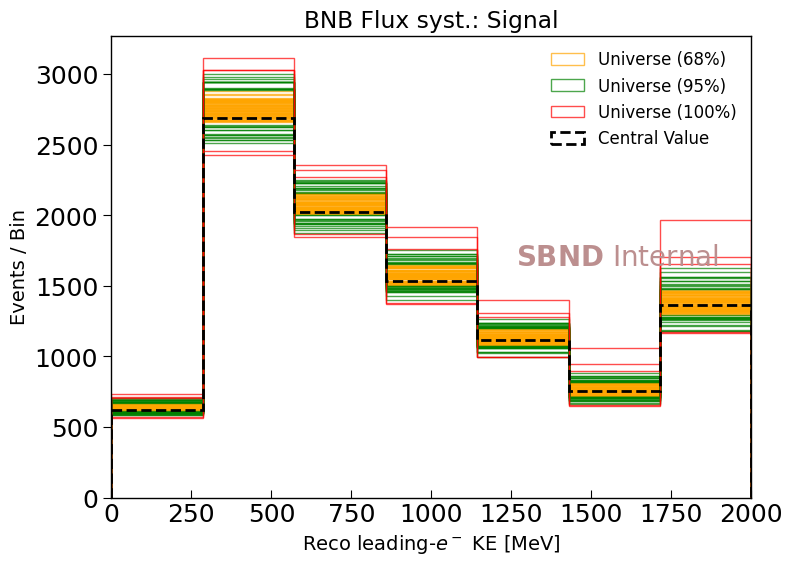

<Figure size 800x600 with 0 Axes>

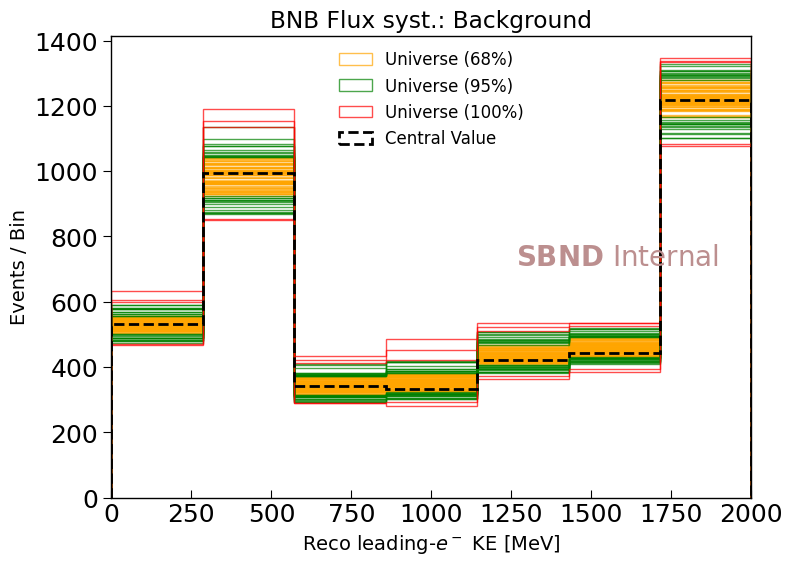

<Figure size 800x600 with 0 Axes>

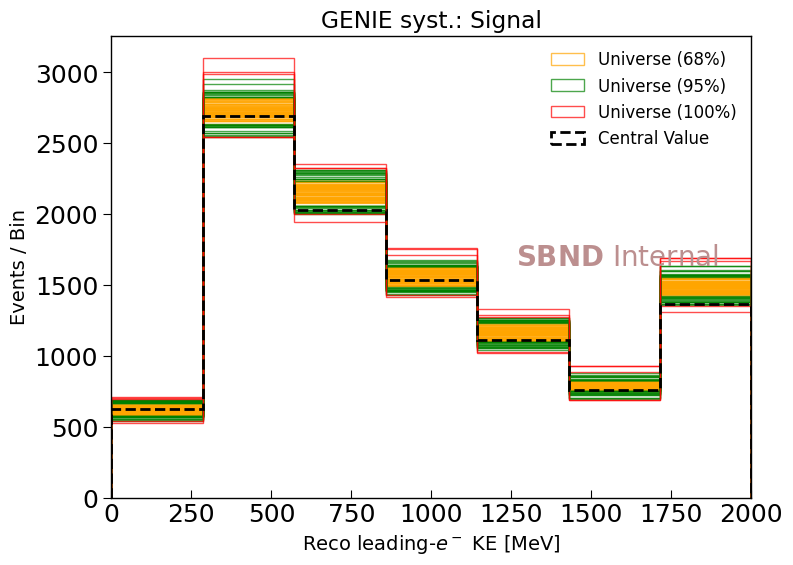

<Figure size 800x600 with 0 Axes>

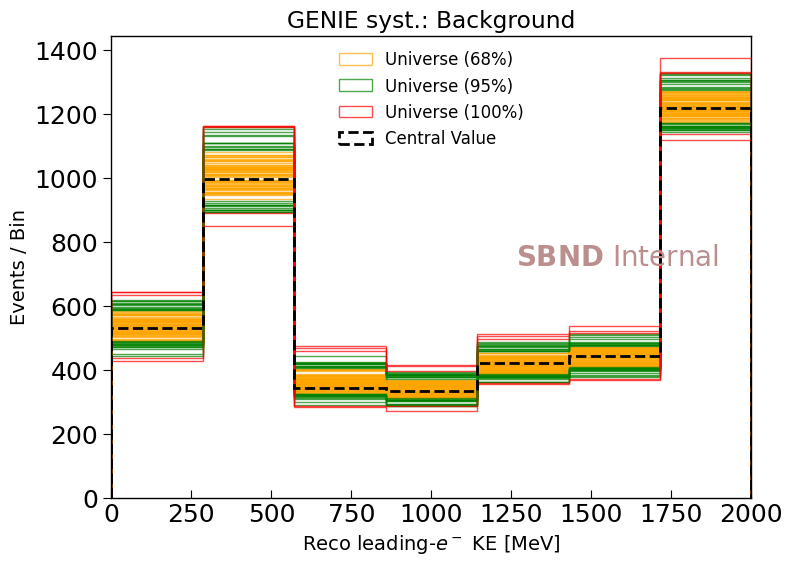

<Figure size 800x600 with 0 Axes>

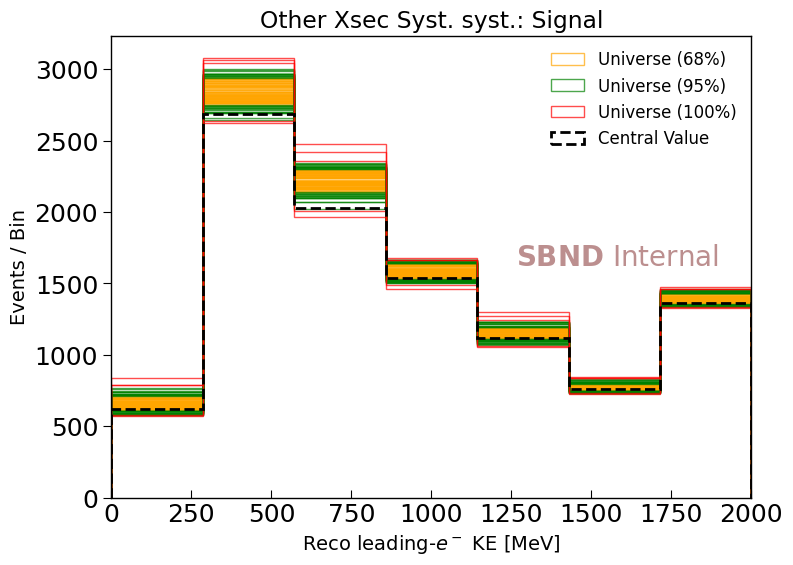

<Figure size 800x600 with 0 Axes>

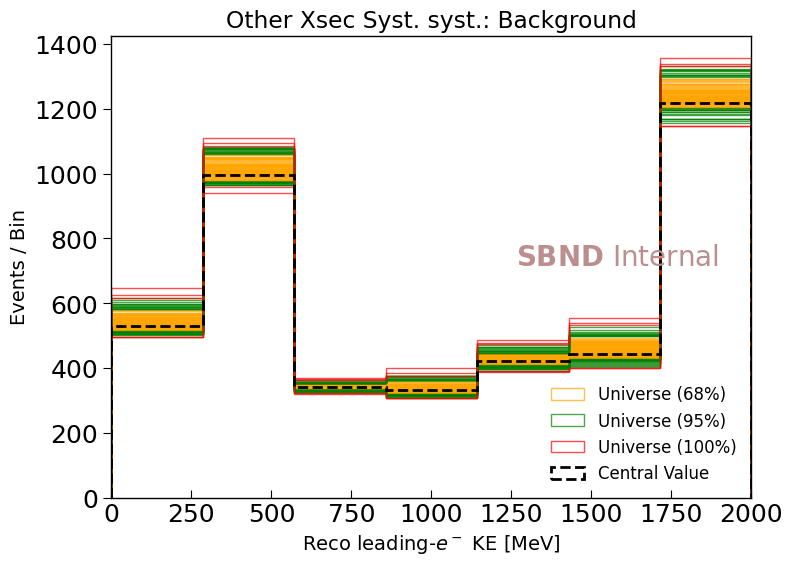

<Figure size 800x600 with 0 Axes>

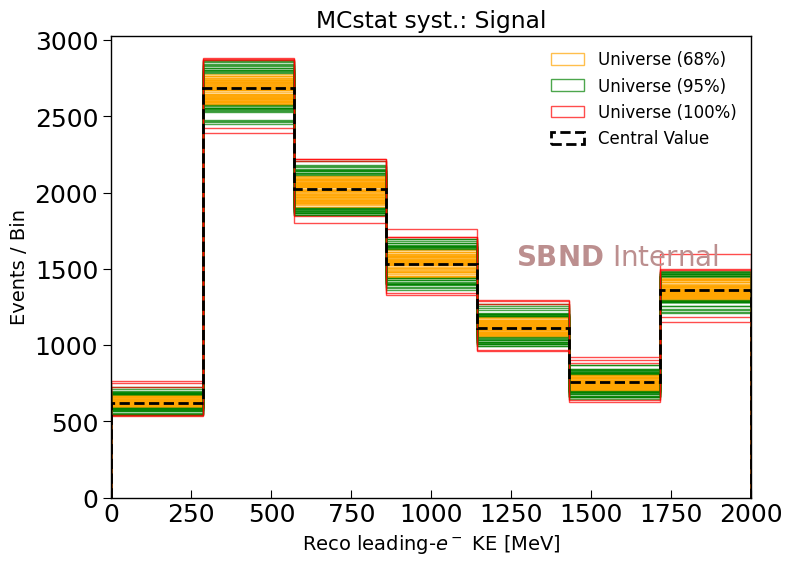

<Figure size 800x600 with 0 Axes>

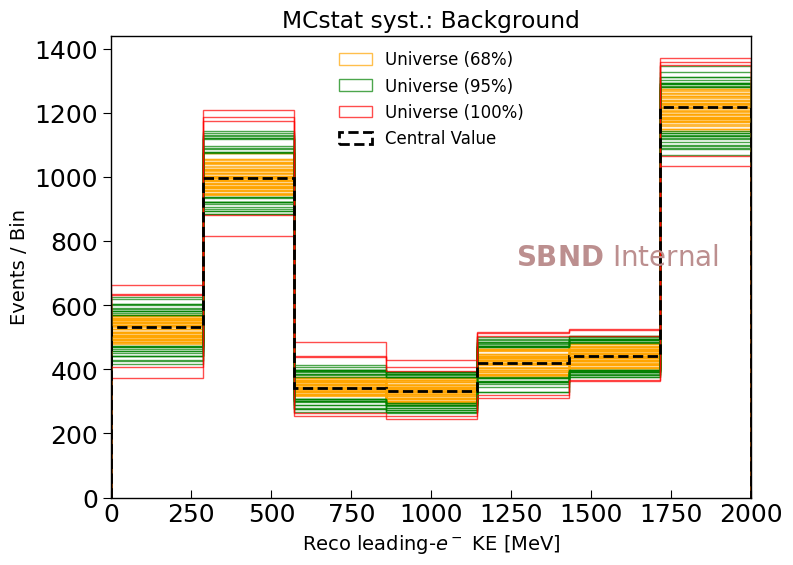

<Figure size 800x600 with 0 Axes>

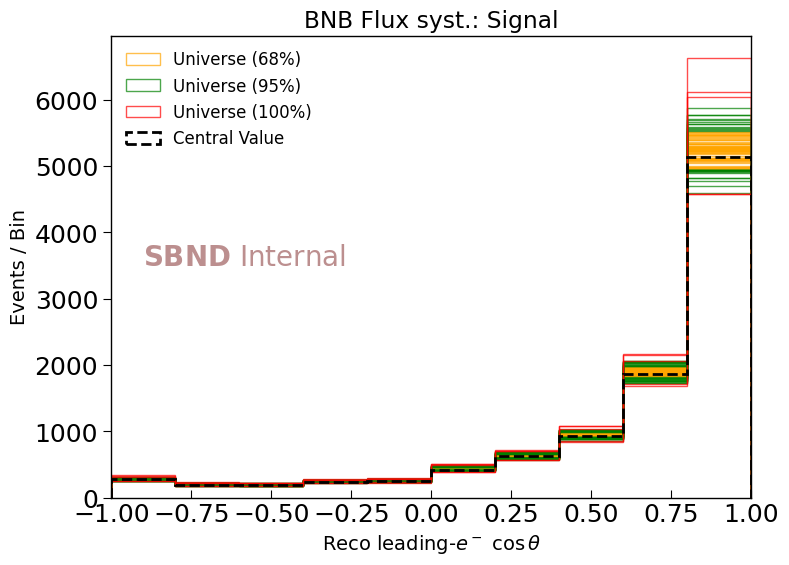

<Figure size 800x600 with 0 Axes>

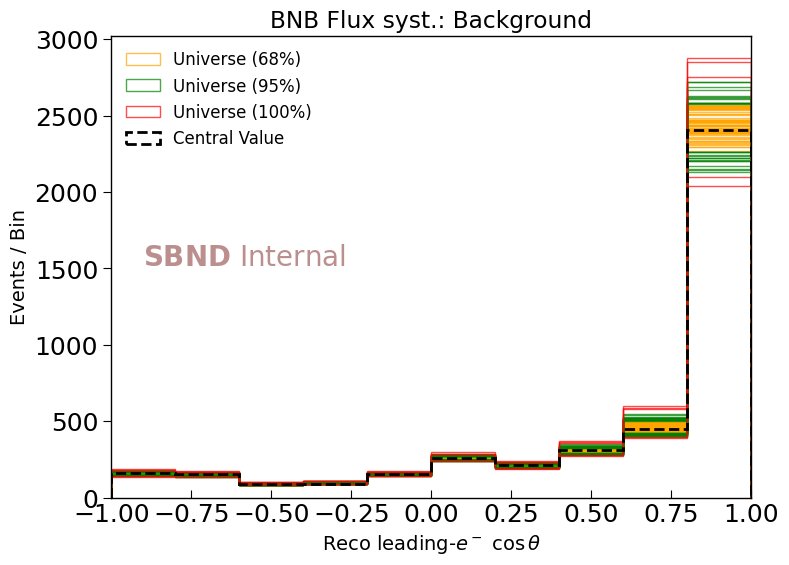

<Figure size 800x600 with 0 Axes>

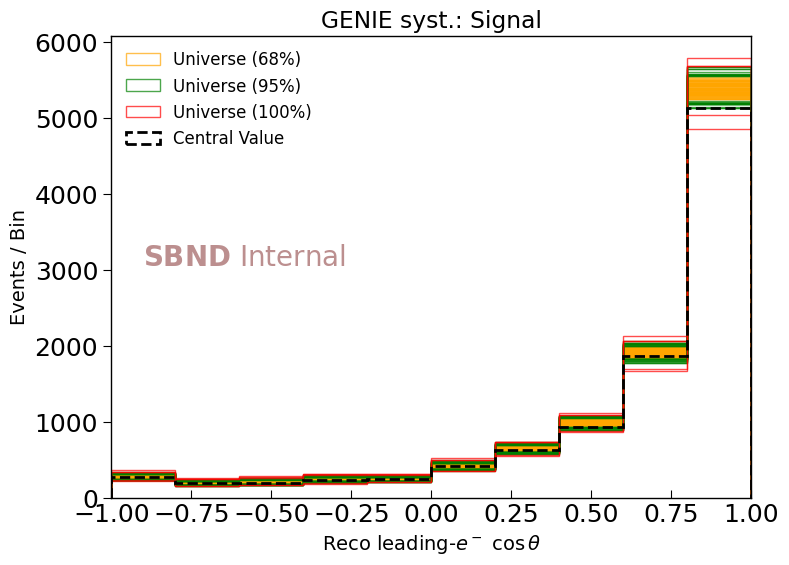

<Figure size 800x600 with 0 Axes>

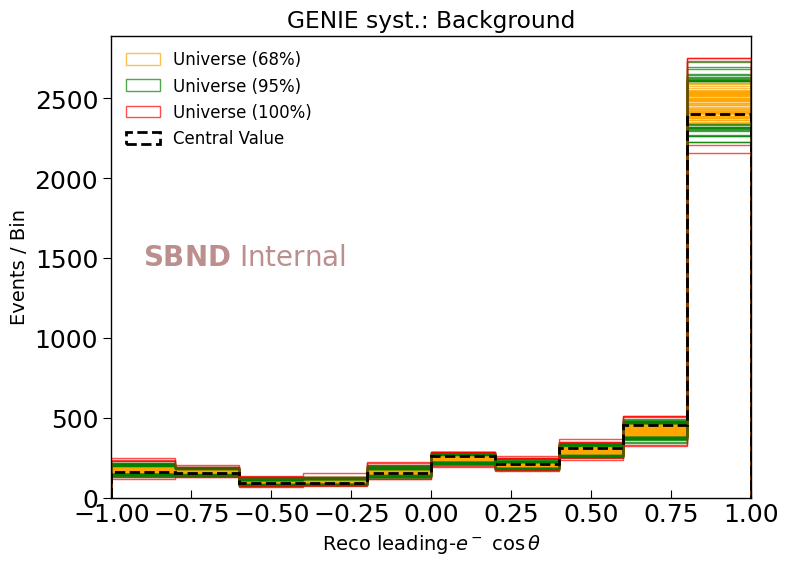

<Figure size 800x600 with 0 Axes>

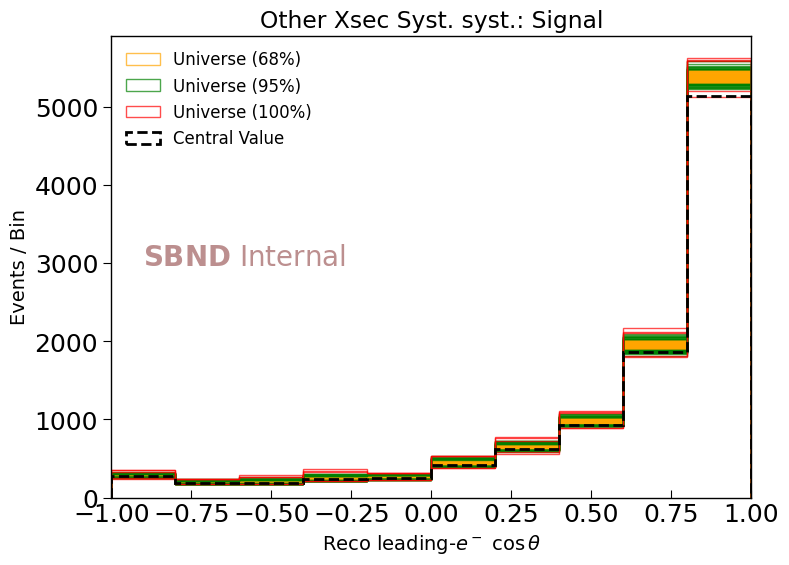

<Figure size 800x600 with 0 Axes>

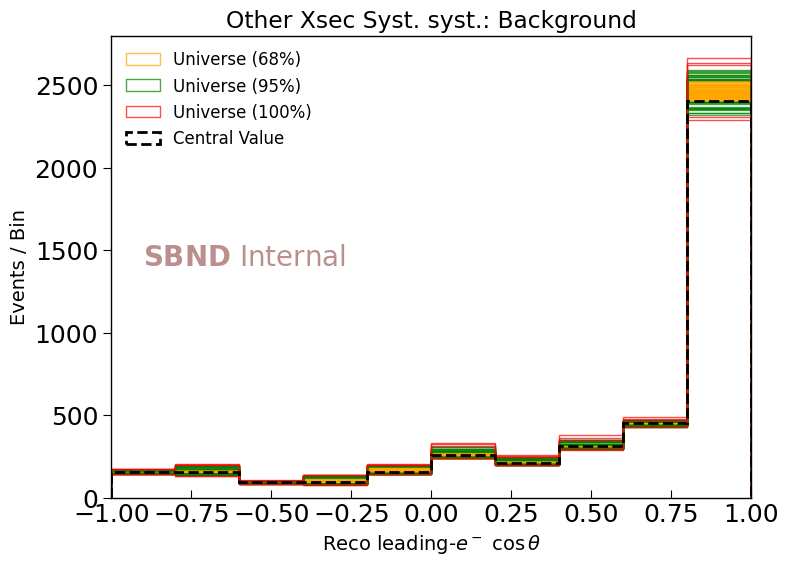

<Figure size 800x600 with 0 Axes>

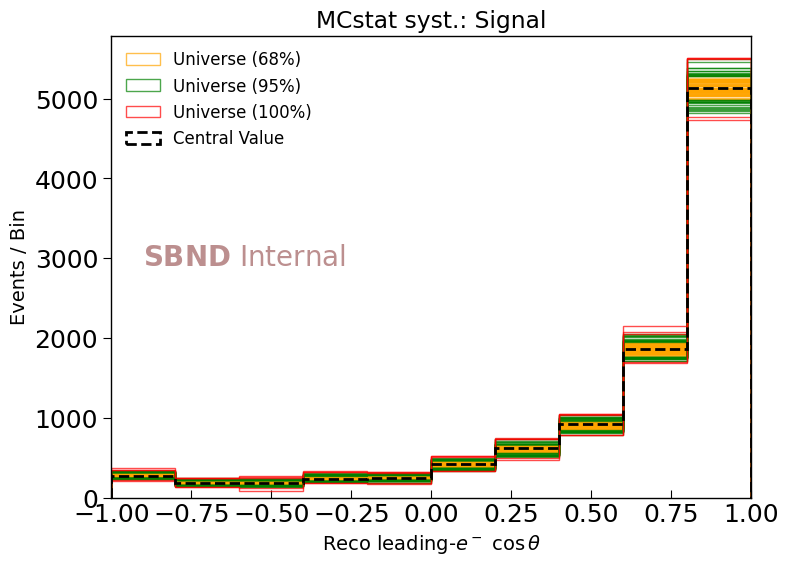

<Figure size 800x600 with 0 Axes>

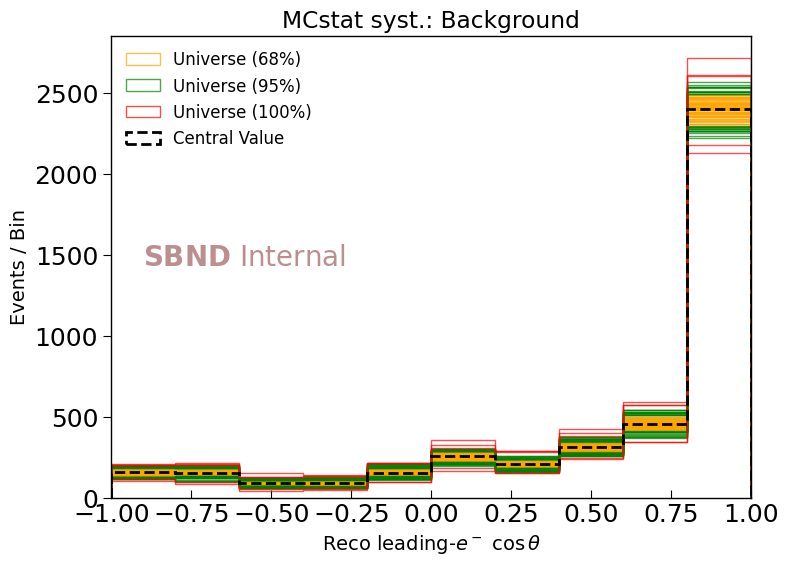

<Figure size 800x600 with 0 Axes>

Universe plots -> plots_syst/univ/


In [22]:
def savefig(fig, name, sub=''):
    d = os.path.join(PLOT_DIR, sub) if sub else PLOT_DIR
    os.makedirs(d, exist_ok=True)
    fig.savefig(os.path.join(d, f'{name}.png'), dpi=150, bbox_inches='tight')
    display(fig)       # show inline in notebook
    plt.close(fig)

for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    for src, ud in univ_results[vcfg.name].items():
        for categ, cv_arr, ua in [
            ('Signal',     cv['sig_cv'], ud['sig']),
            ('Background', cv['bkg_cv'], ud['bkg']),
        ]:
            try:
                plot_univ_hists(ua, cv_arr, SRC_LABEL[src], vcfg, categ_name=categ)
                fig = plt.gcf()   # grab whatever was just created
                savefig(fig, f'{vcfg.name}_{src}_{categ.lower()}_univs', 'univ')
            except Exception as e:
                print(f'  [WARN] {vcfg.name}/{src}/{categ}: {e}')
                plt.close('all')

print('Universe plots -> plots_syst/univ/')

## 11. Plots: Covariance Heatmaps

In [23]:
import re

def format_heatmap_value(v):
    if np.isnan(v): return ""
    av = abs(v)
    if av == 0: return "0"
    if av < 1:
        return f"{v:.4f}"
    elif av < 1e3:
        return f"{v:.2f}"
    mantissa, exponent = f"{v:.2e}".split("e")
    return rf"${mantissa}\times10^{{{int(exponent)}}}$"

def plot_heatmap_custom(matrix, title, vcfg, axis_labels=None,
                        cmap='viridis', vmin=None, vmax=None):
    """Heatmap with bin-range tick labels and formatted cell annotations."""
    try:
        from analysis_village.unfolding.utils import bin_range_labels, get_text_color
        raw     = bin_range_labels(vcfg.bins)
        t_lbls  = [re.sub(r'(\d+)\.0+(?!\d)', r'\1', l) for l in raw]
        _get_tc = get_text_color
    except Exception:
        t_lbls  = [f'{vcfg.bins[i]:.0f}–{vcfg.bins[i+1]:.0f}'
                   for i in range(len(vcfg.bins)-1)]
        _get_tc = lambda v: 'white'

    n        = len(vcfg.bins) - 1
    unif     = np.arange(n + 1, dtype=float)
    tick_pos = 0.5 * (unif[:-1] + unif[1:])
    extent   = [unif[0], unif[-1], unif[0], unif[-1]]

    fig, ax = plt.subplots(figsize=(max(6, n*0.8), max(5, n*0.7)))
    im = ax.imshow(matrix, extent=extent, origin='lower',
                   cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=9)

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(t_lbls, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(tick_pos)
    ax.set_yticklabels(t_lbls, fontsize=8)
    ax.tick_params(axis='both', labelsize=8)

    xlbl, ylbl = axis_labels if axis_labels else [vcfg.var_plot_name]*2
    ax.set_xlabel(xlbl, fontsize=11)
    ax.set_ylabel(ylbl, fontsize=11)
    ax.set_title(title, fontsize=12)

    # Cell annotations
    fsize = max(5, 9 - n//3)   # shrink font for more bins
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            v = matrix[i, j]
            if not np.isnan(v):
                try:    tc = _get_tc(v)
                except: tc = 'white'
                ax.text(tick_pos[j], tick_pos[i],
                        format_heatmap_value(v),
                        ha='center', va='center',
                        color=tc, fontsize=fsize)
    fig.tight_layout()
    return fig, ax

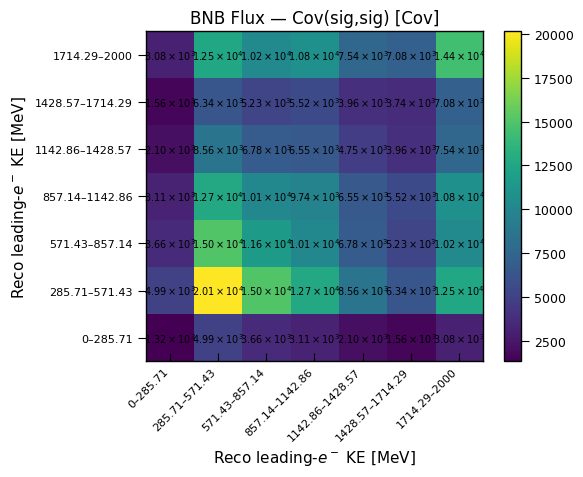

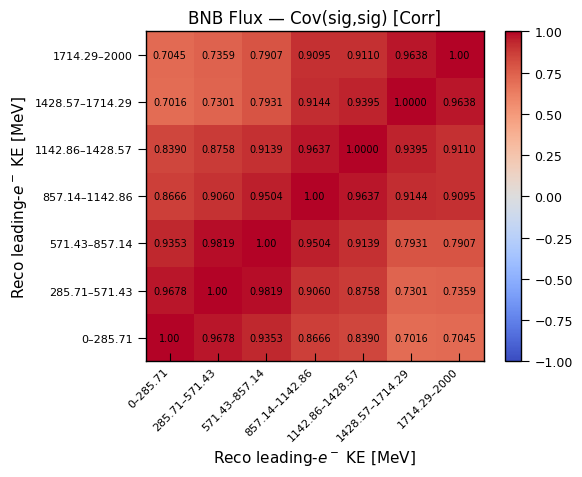

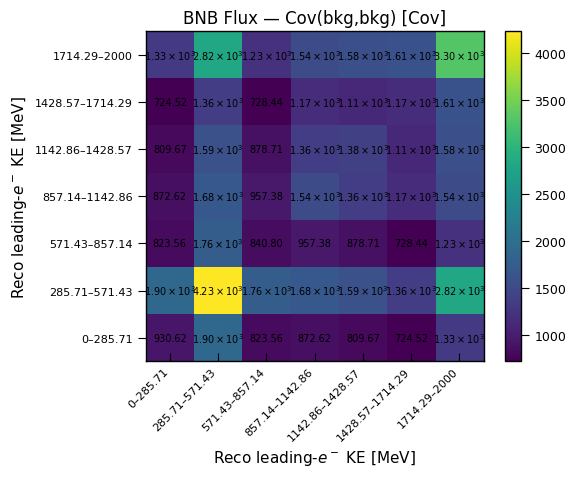

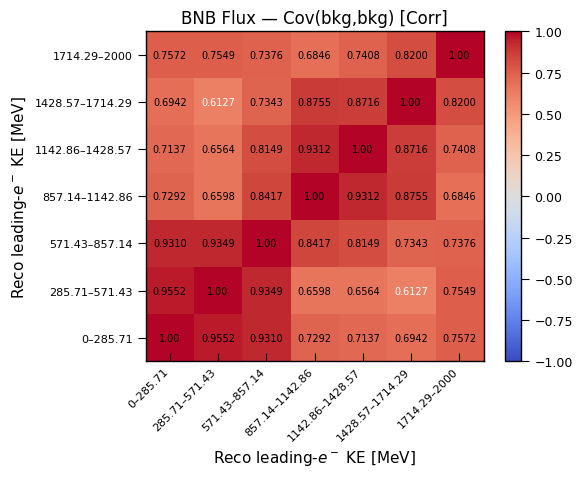

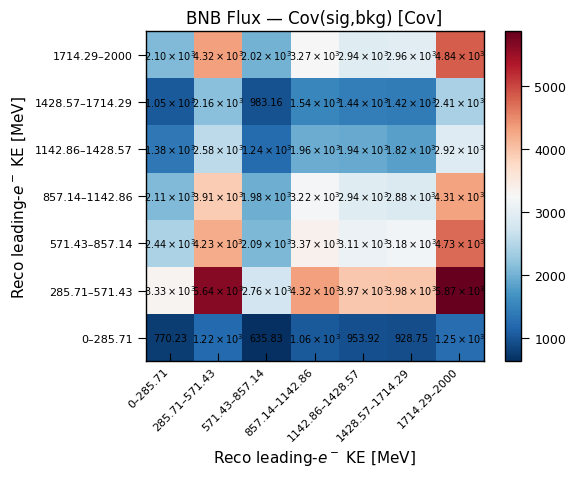

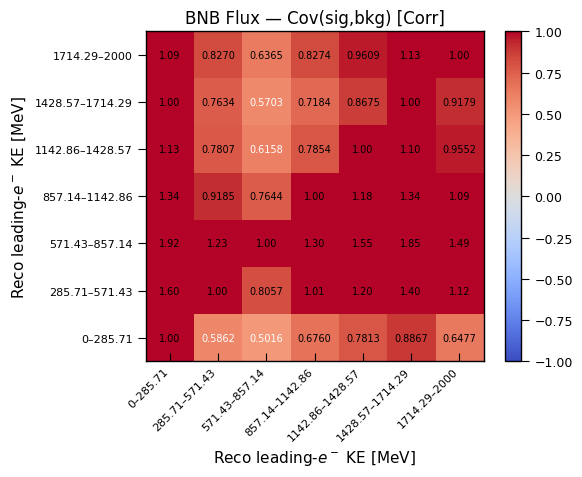

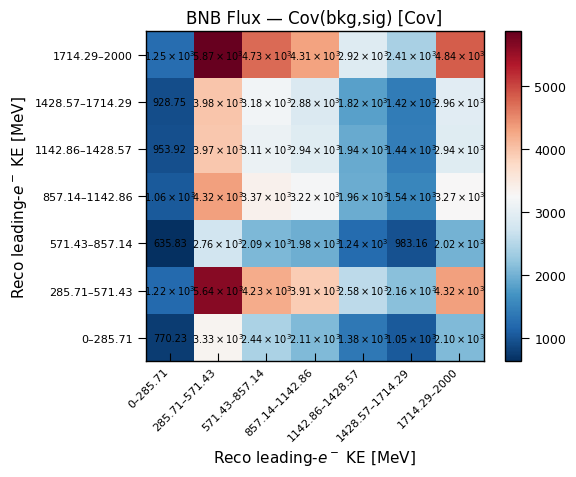

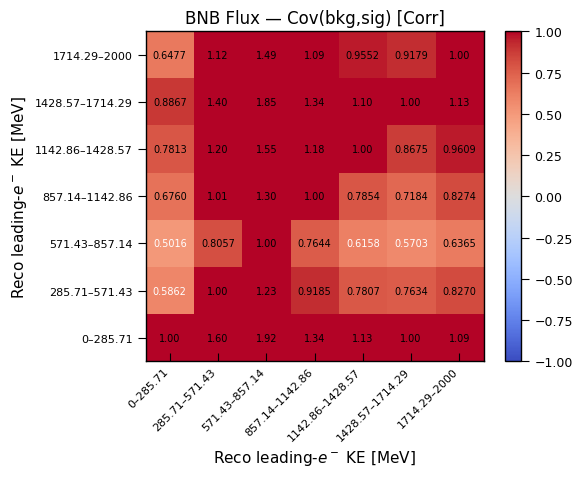

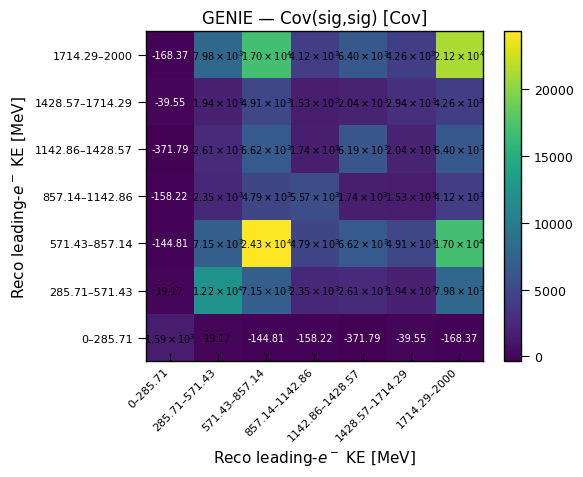

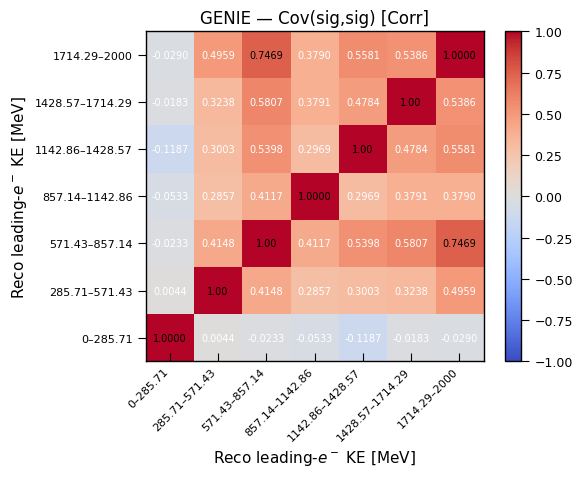

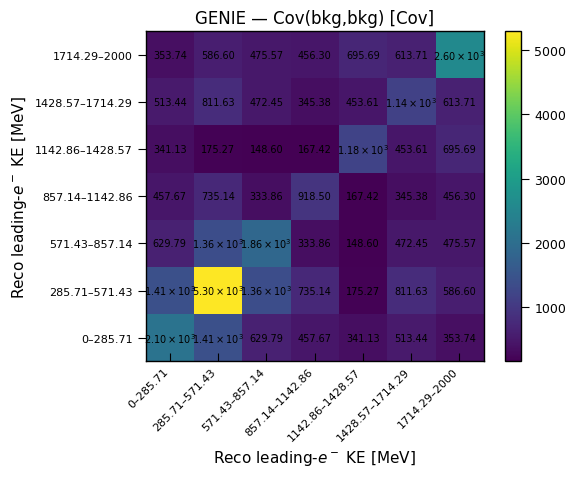

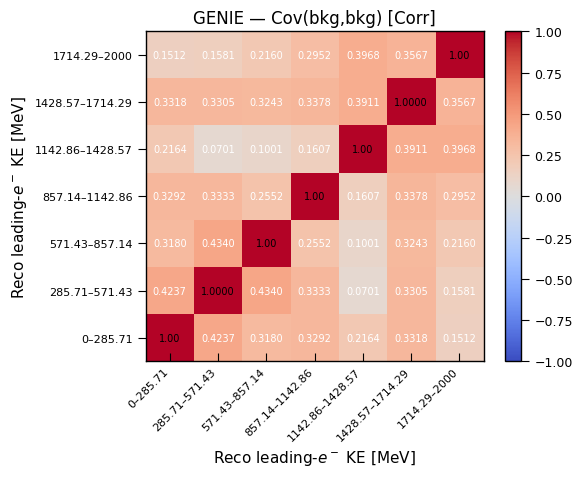

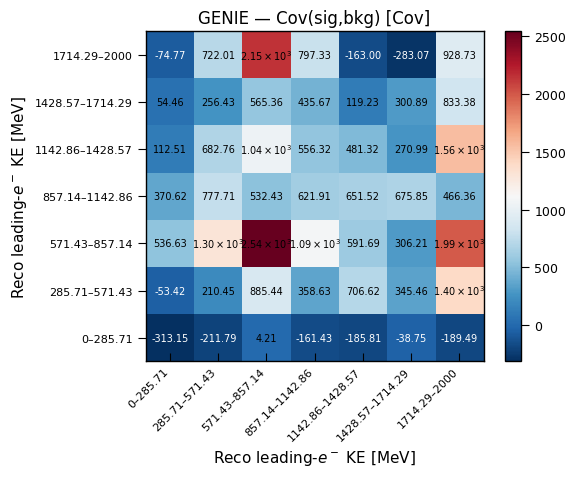

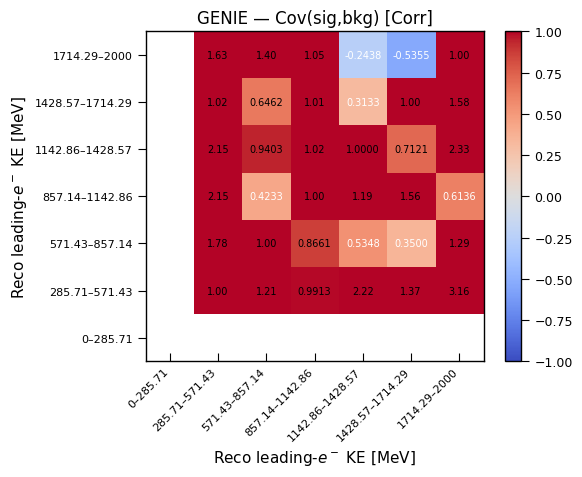

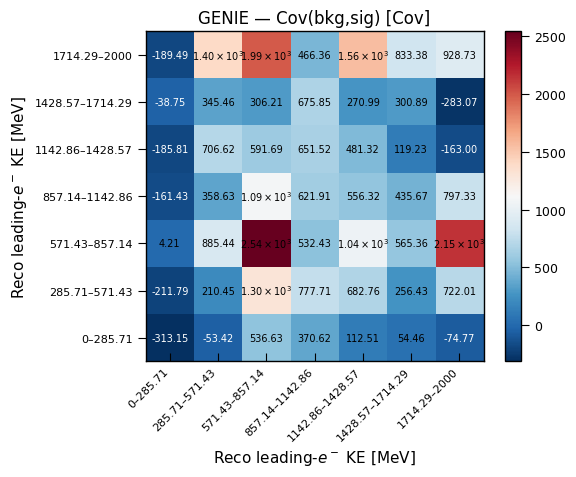

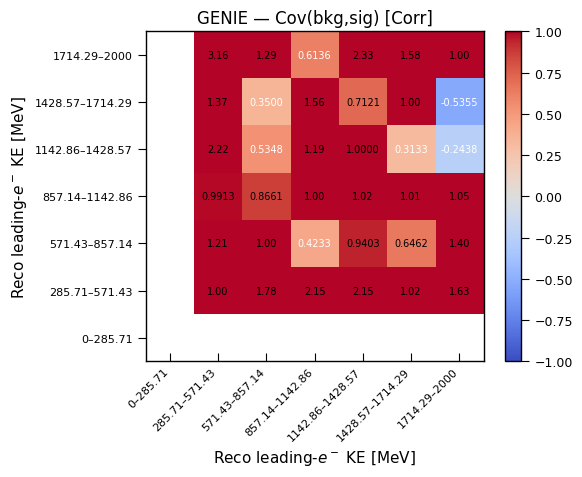

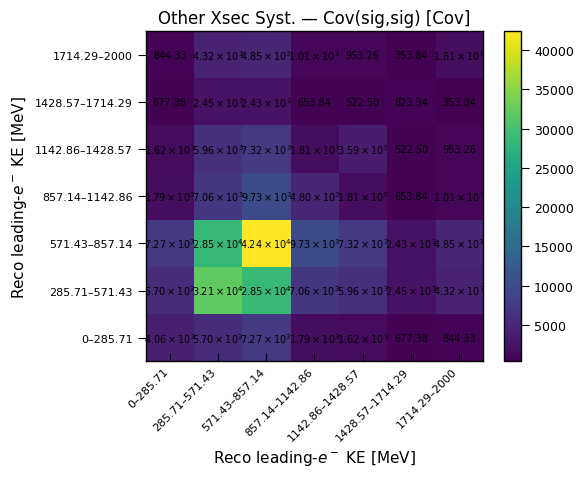

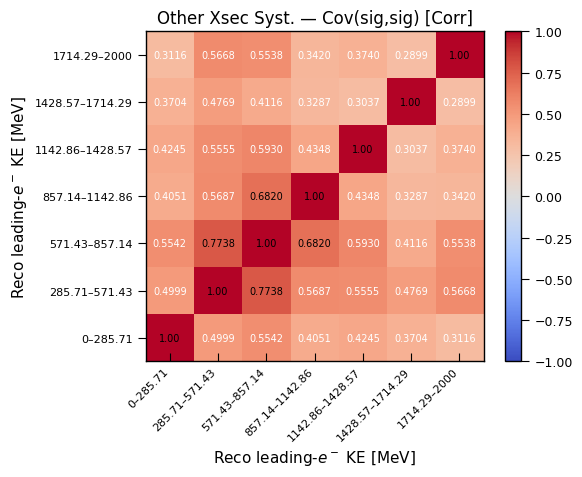

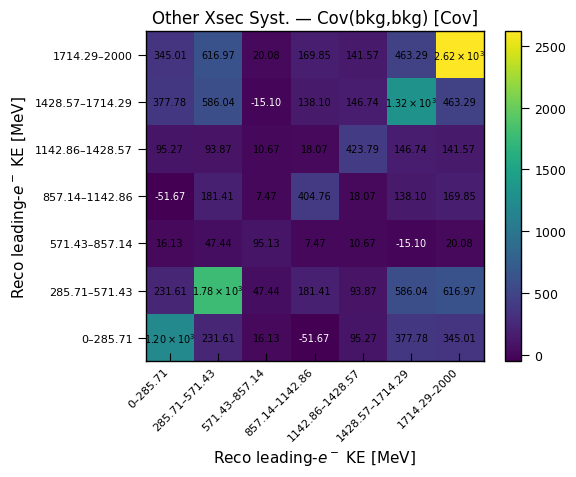

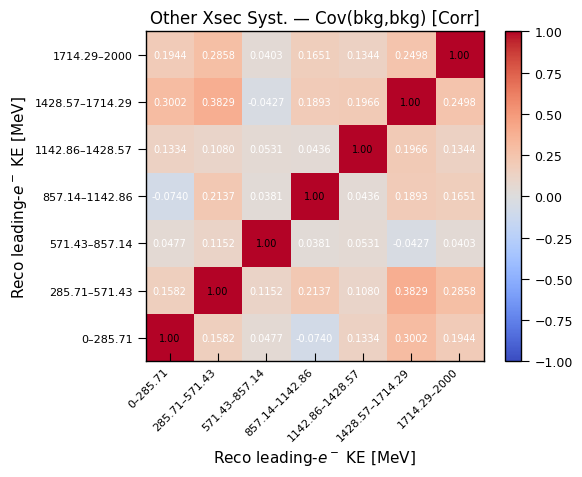

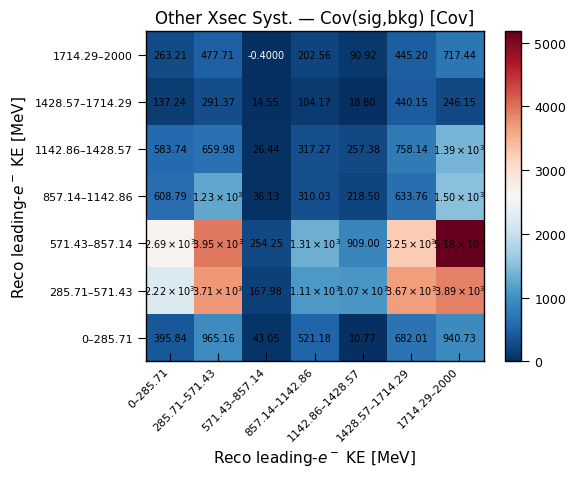

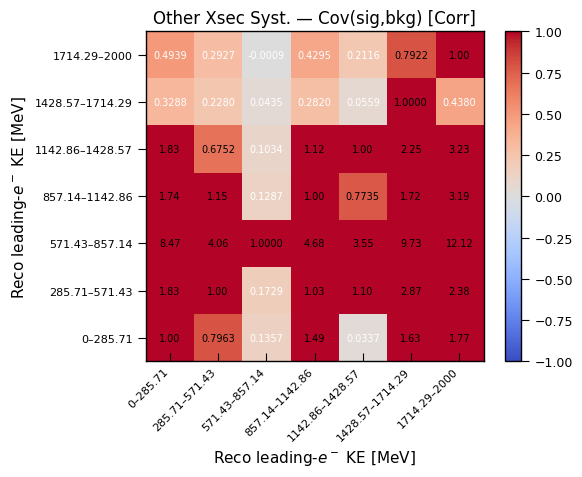

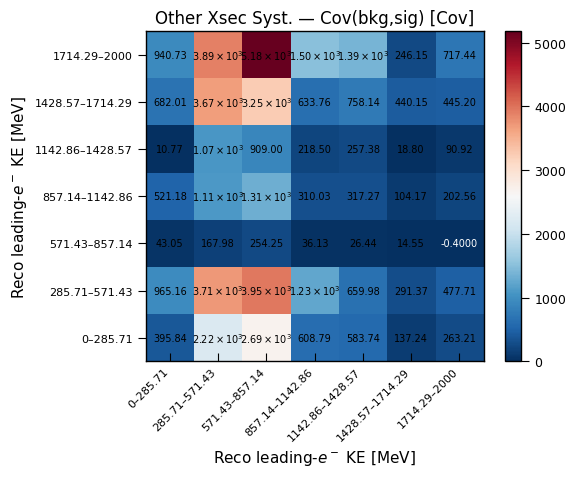

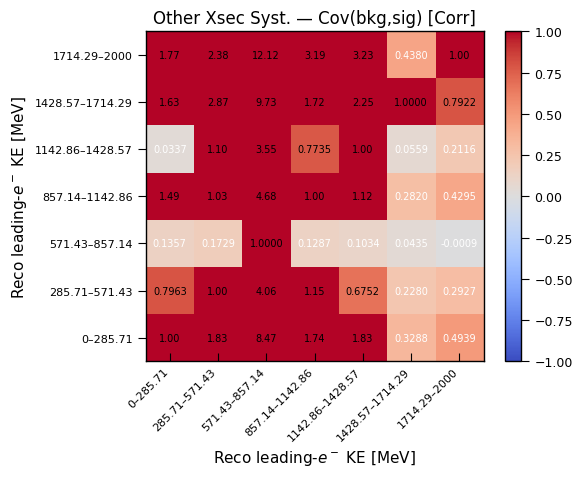

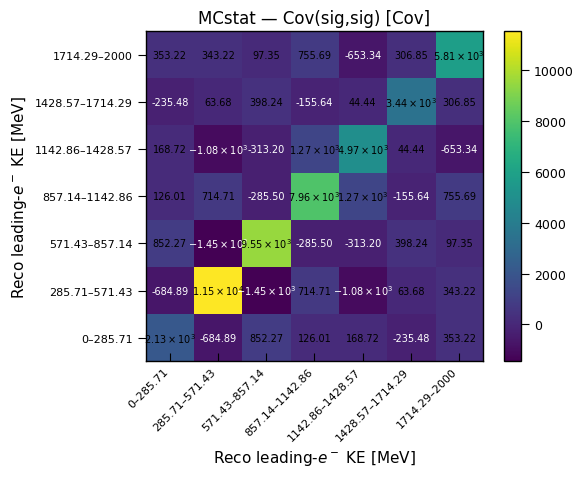

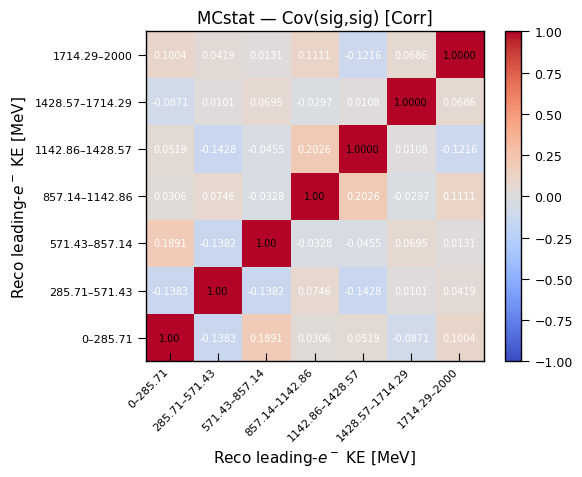

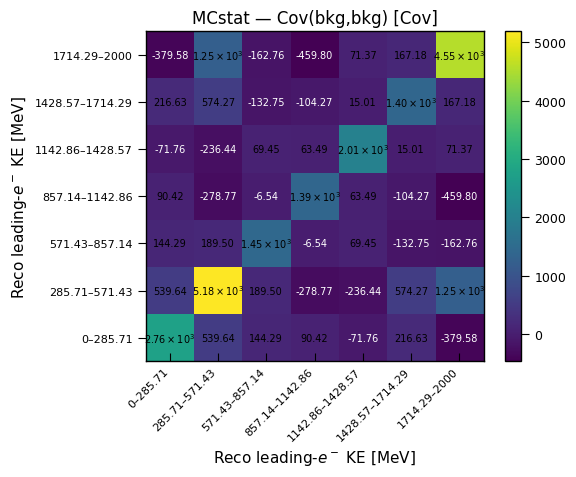

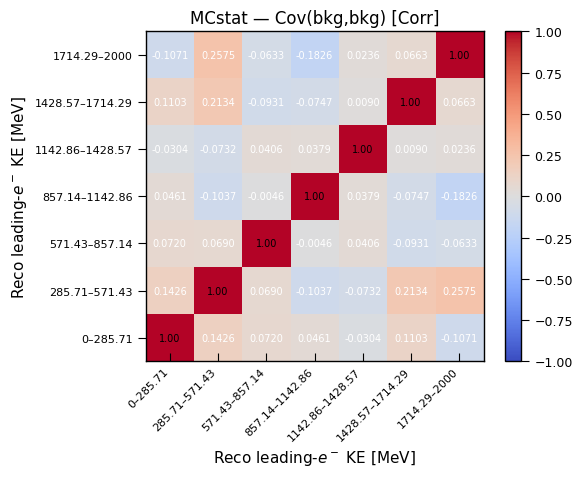

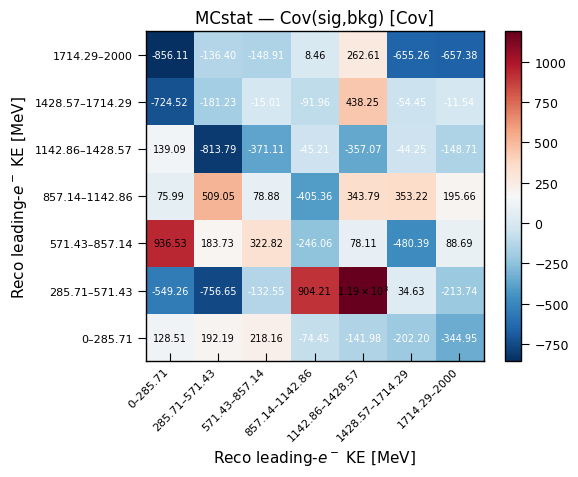

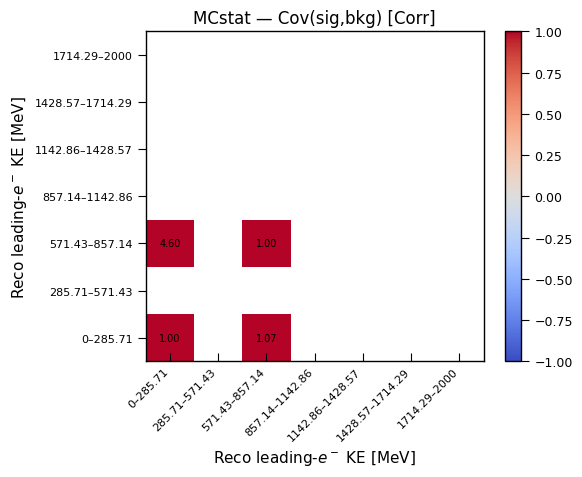

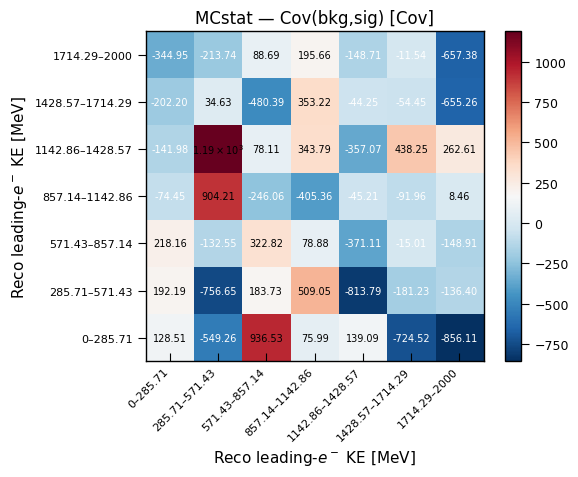

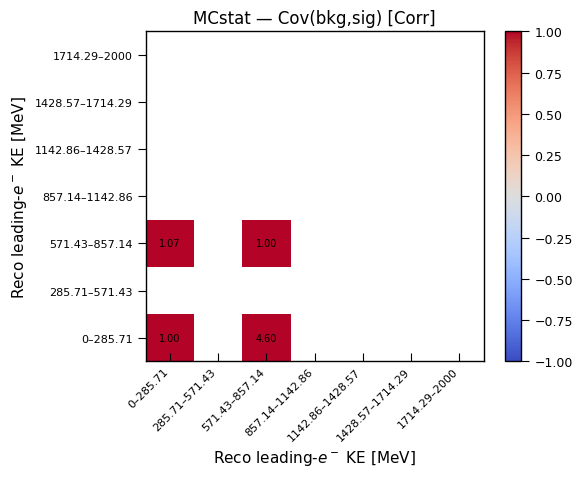

  [WARN] cov reco_ke/pot/cov_ms_ms: 'pot'
  [WARN] cov reco_ke/pot/cov_bs_bs: 'pot'
  [WARN] cov reco_ke/pot/cov_ms_bs: 'pot'
  [WARN] cov reco_ke/pot/cov_bs_ms: 'pot'
  [WARN] cov reco_ke/ntargets/cov_ms_ms: 'ntargets'
  [WARN] cov reco_ke/ntargets/cov_bs_bs: 'ntargets'
  [WARN] cov reco_ke/ntargets/cov_ms_bs: 'ntargets'
  [WARN] cov reco_ke/ntargets/cov_bs_ms: 'ntargets'


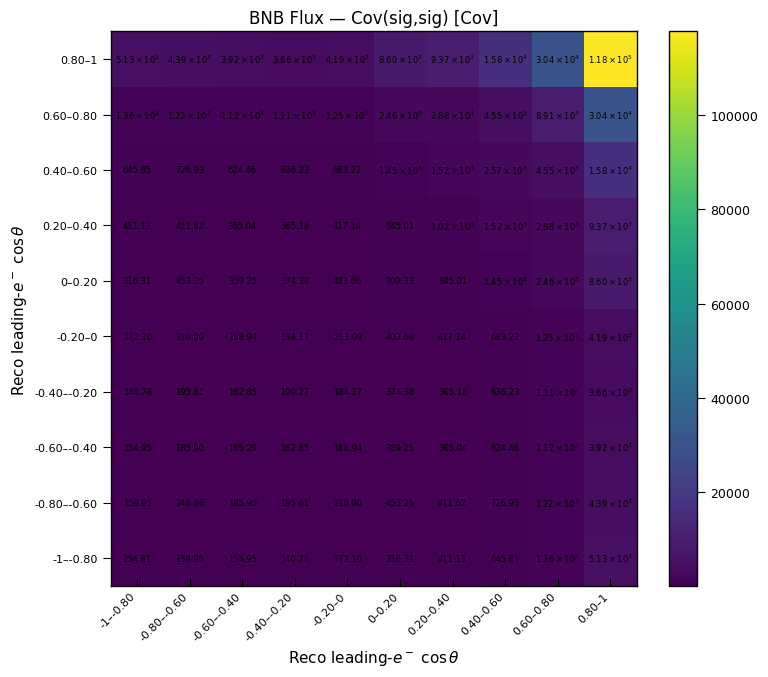

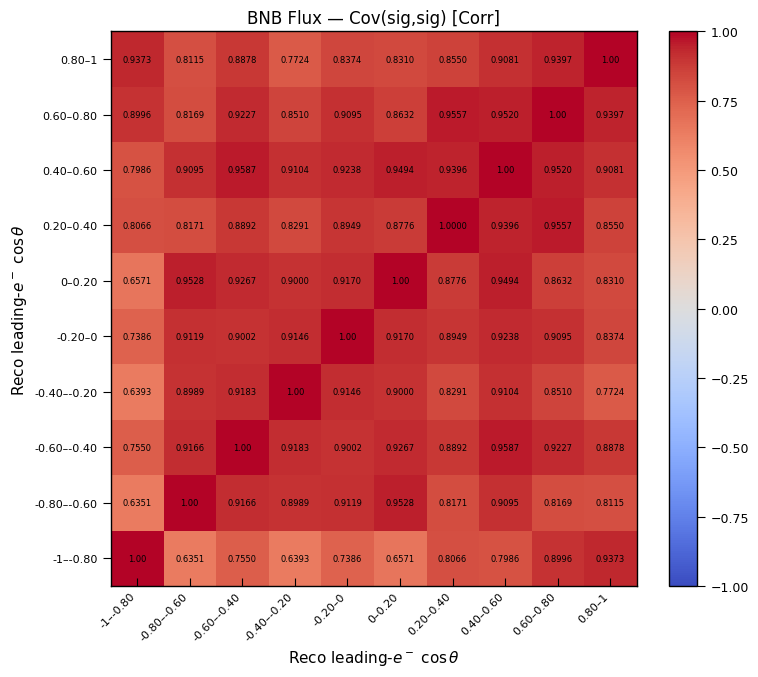

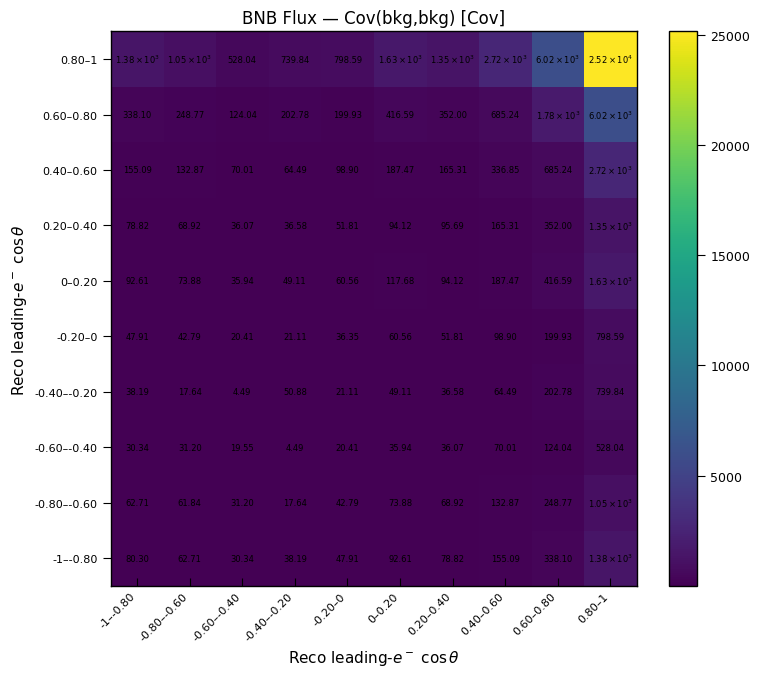

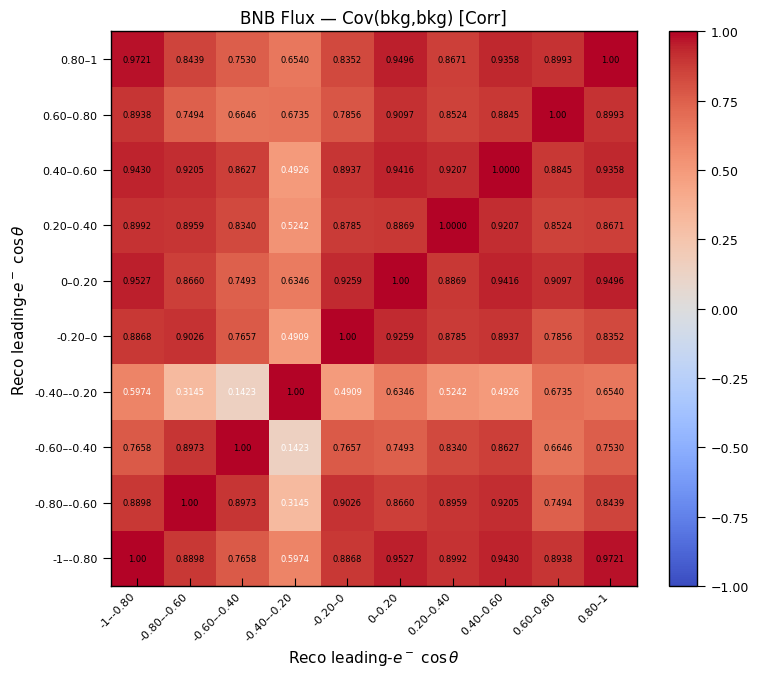

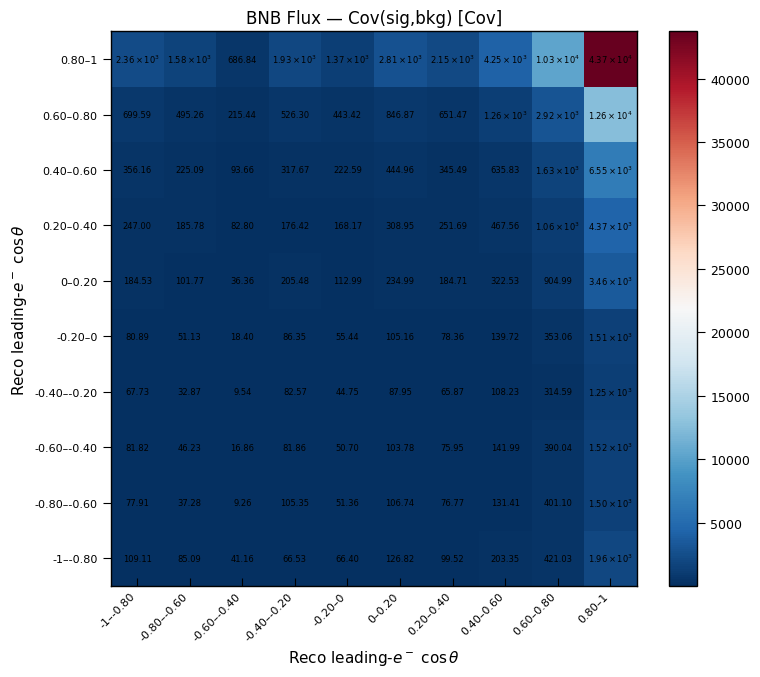

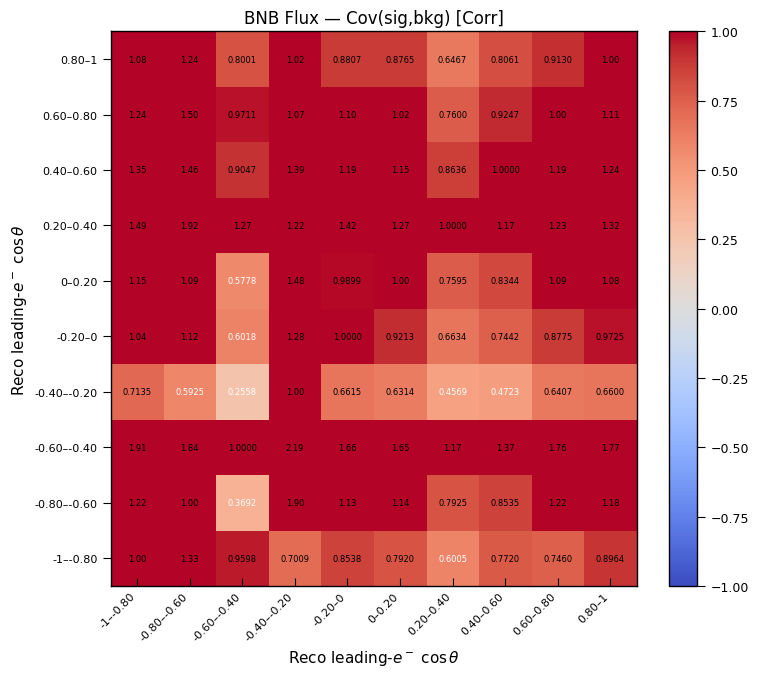

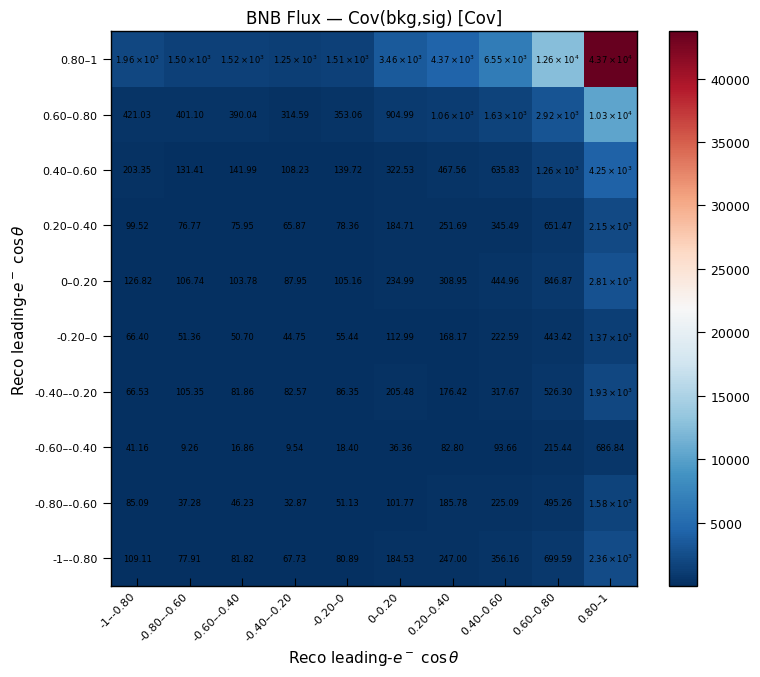

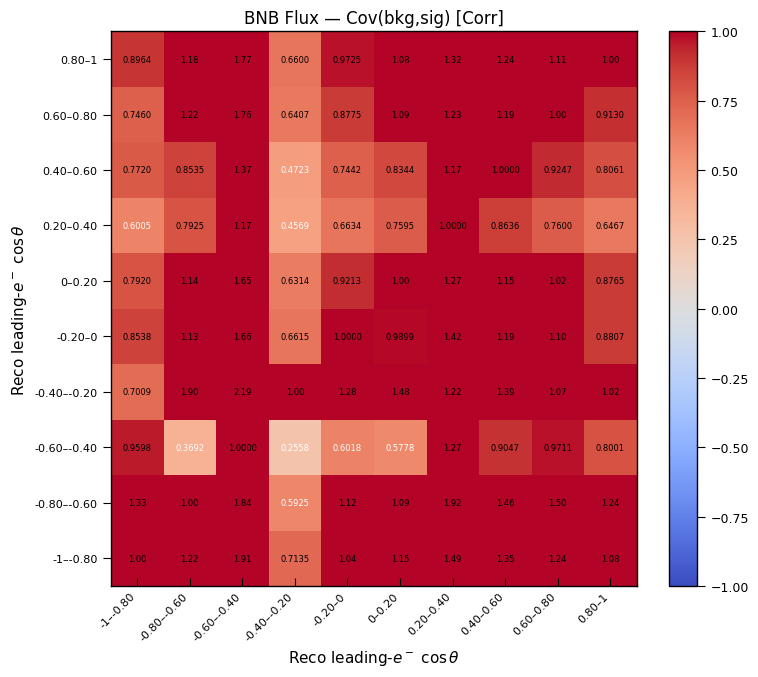

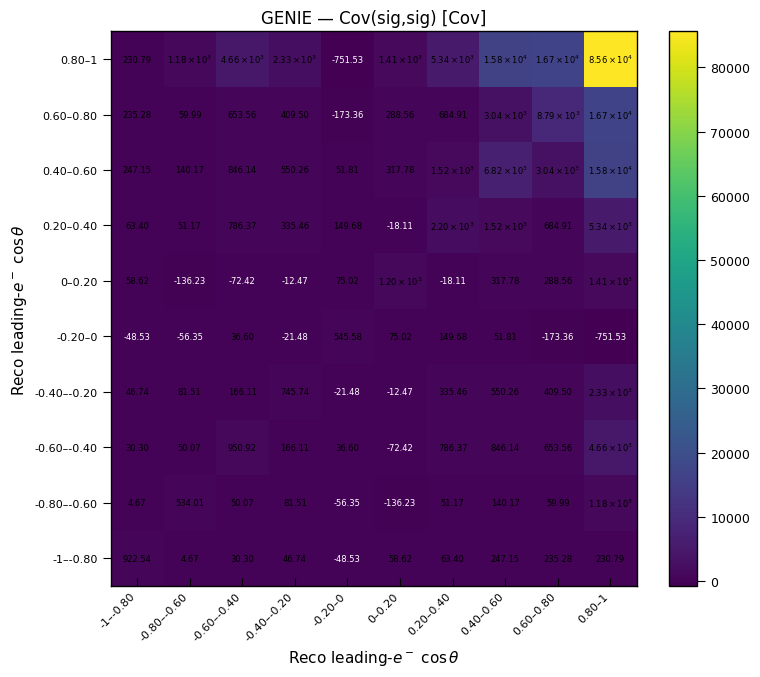

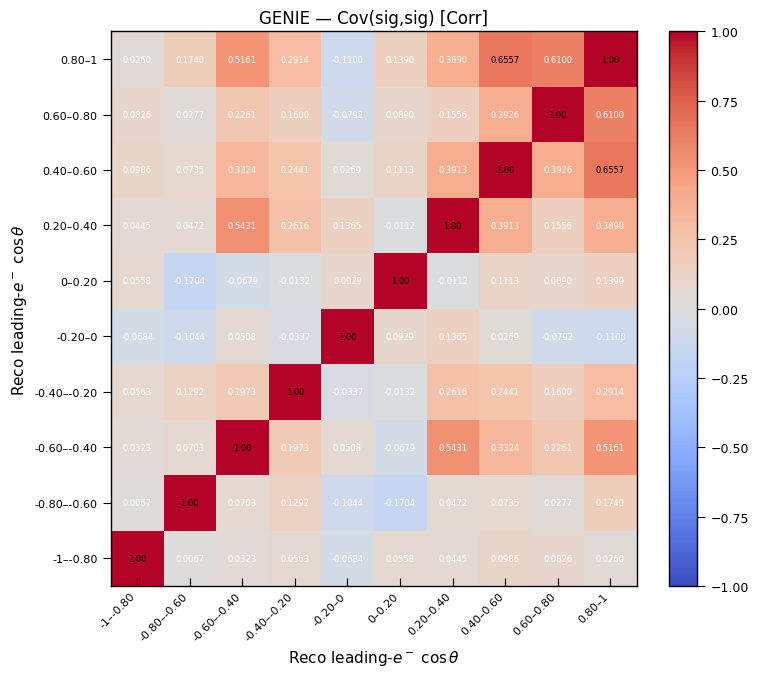

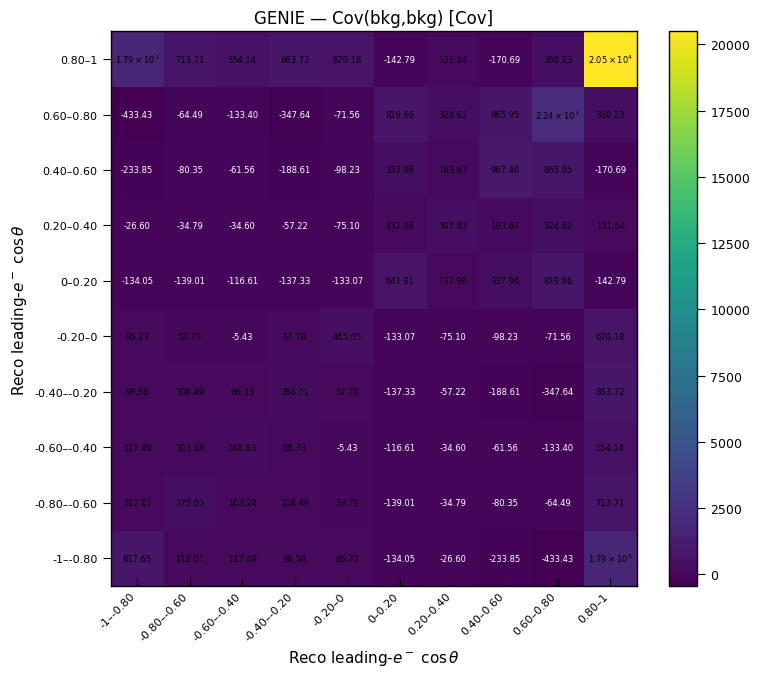

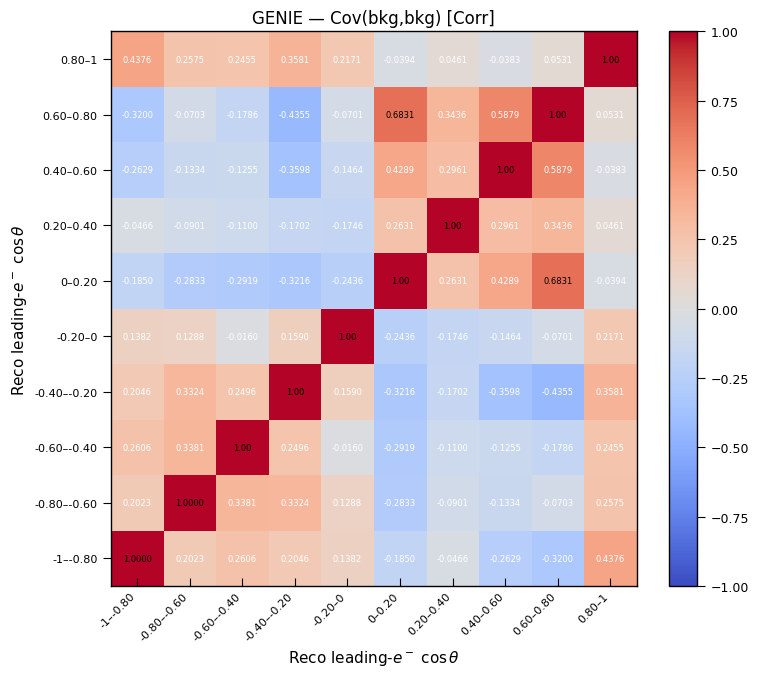

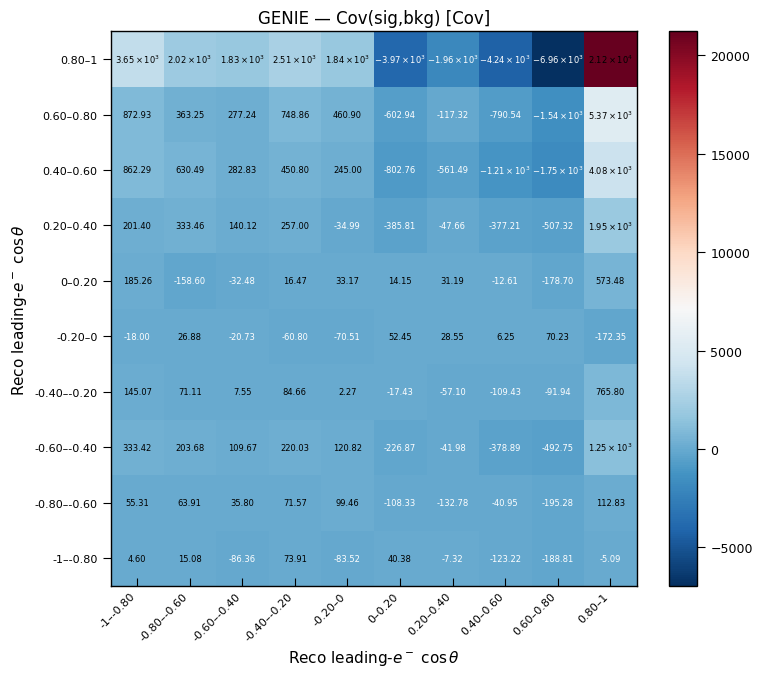

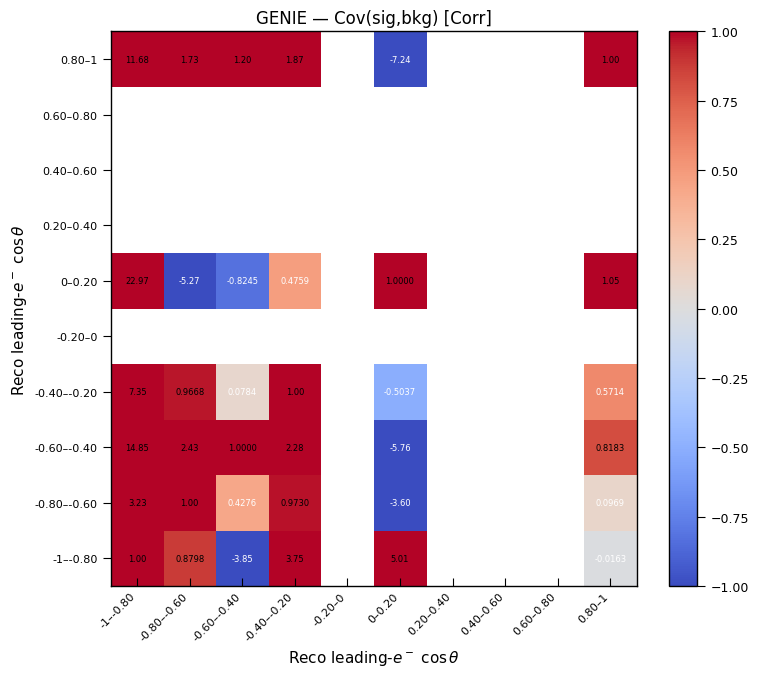

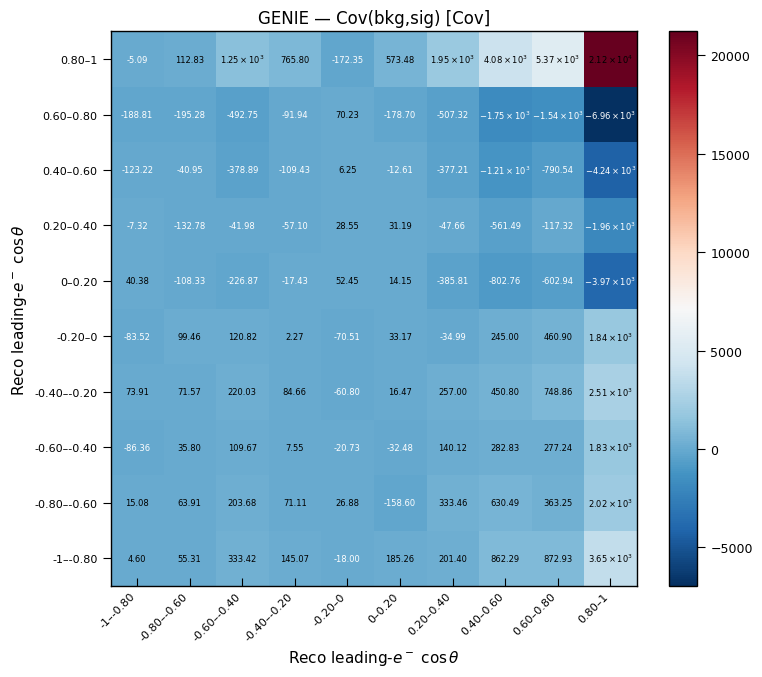

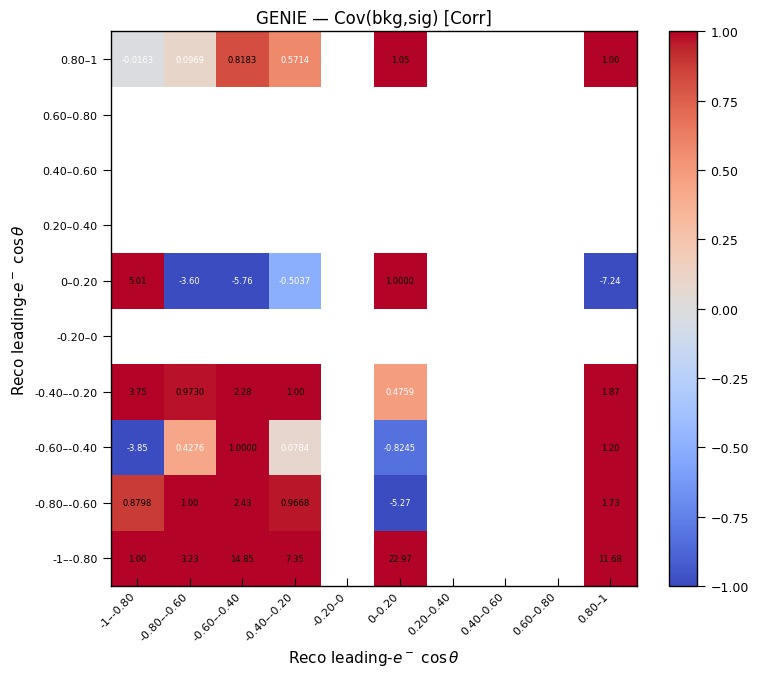

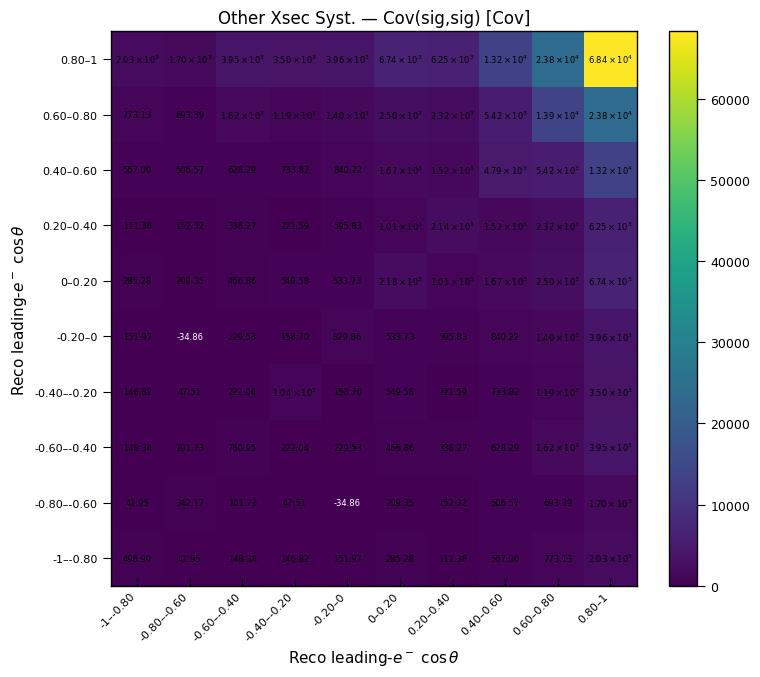

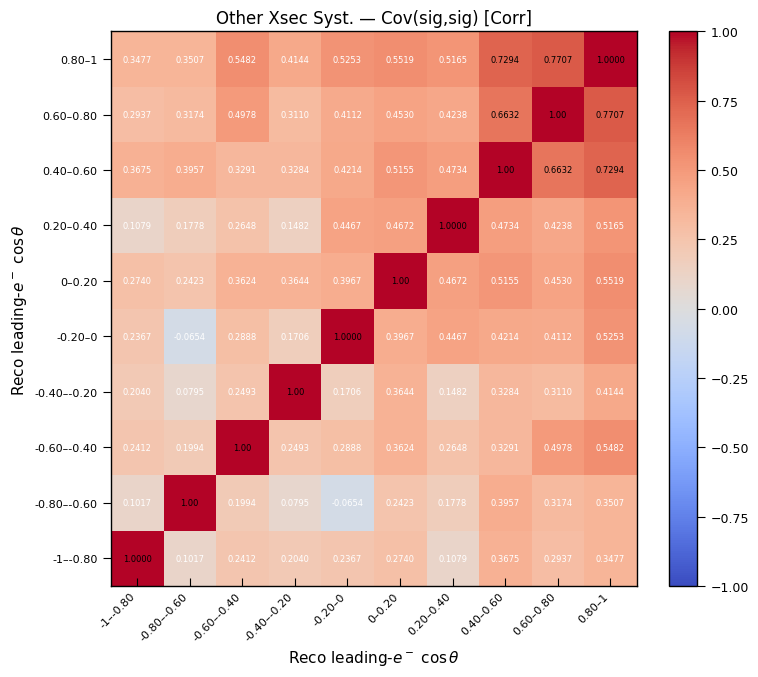

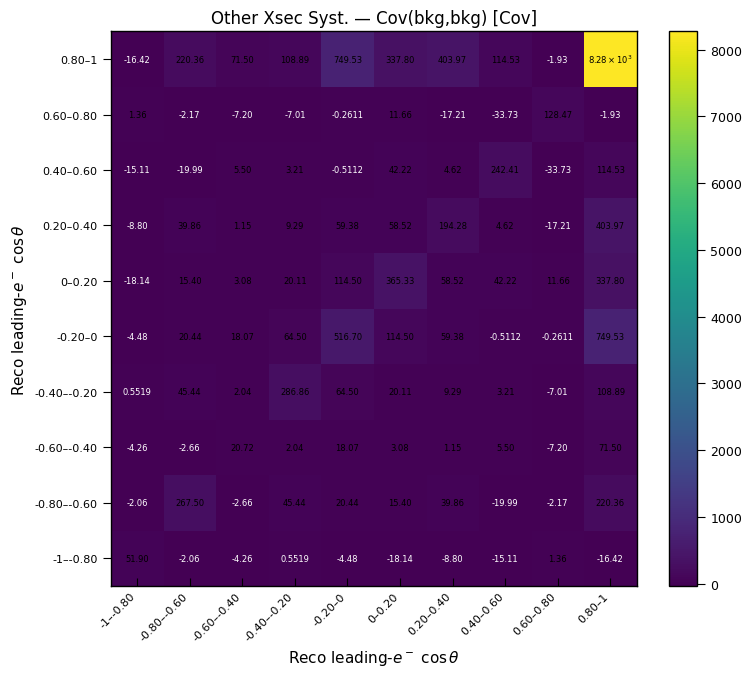

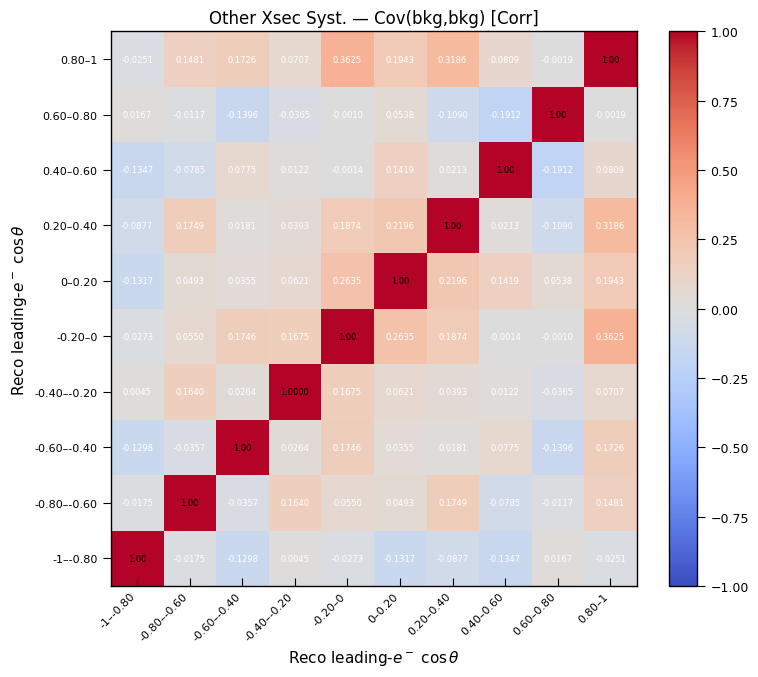

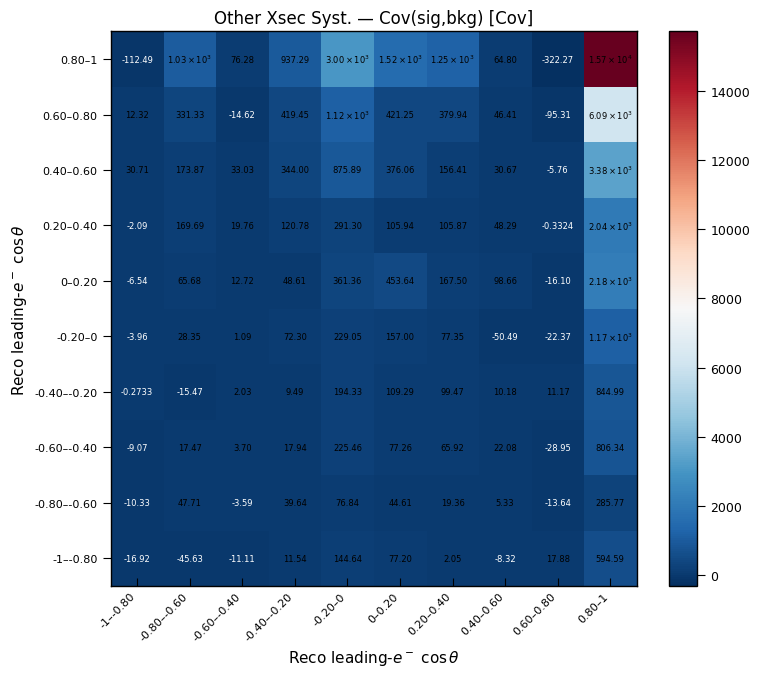

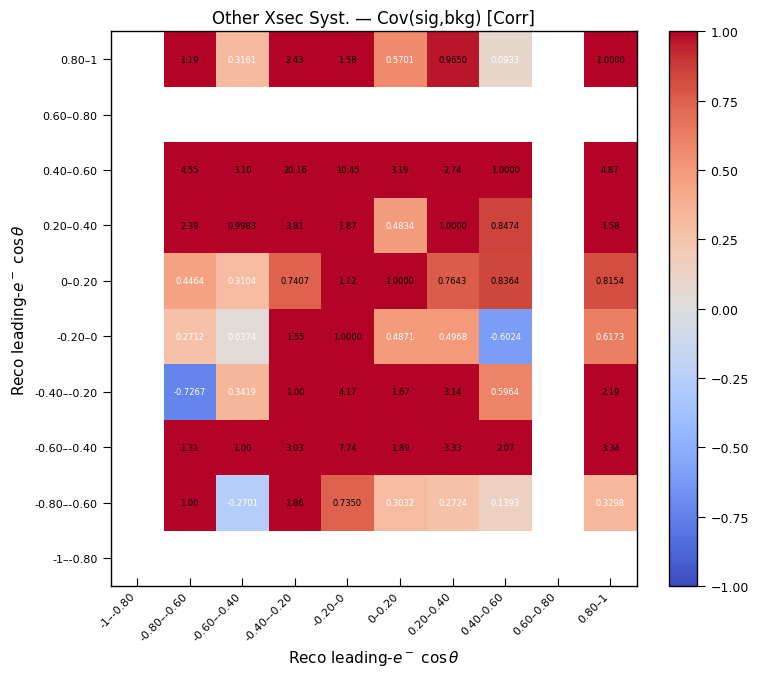

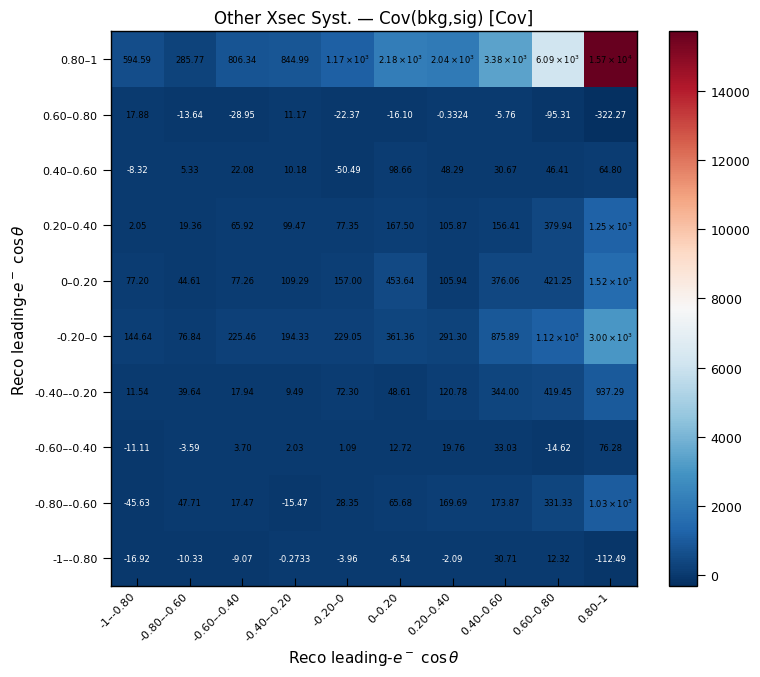

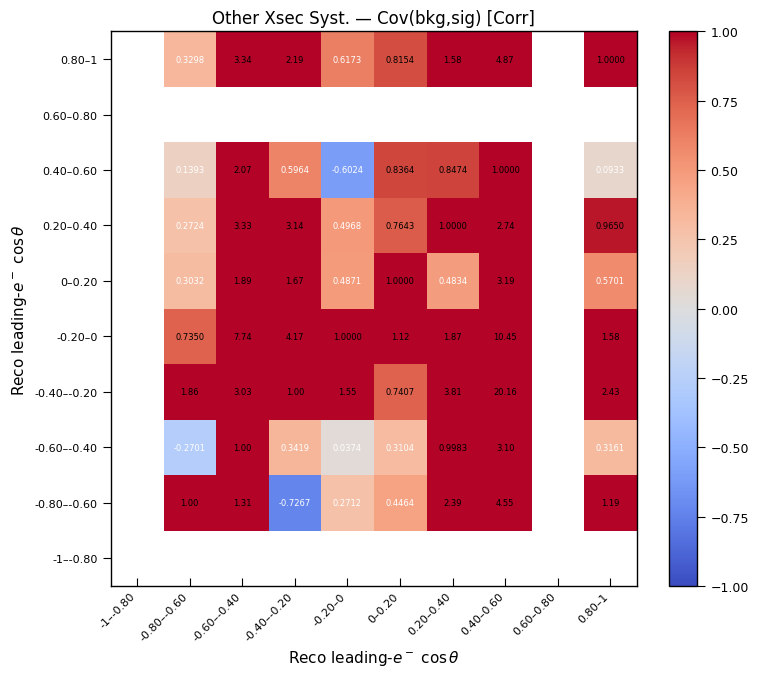

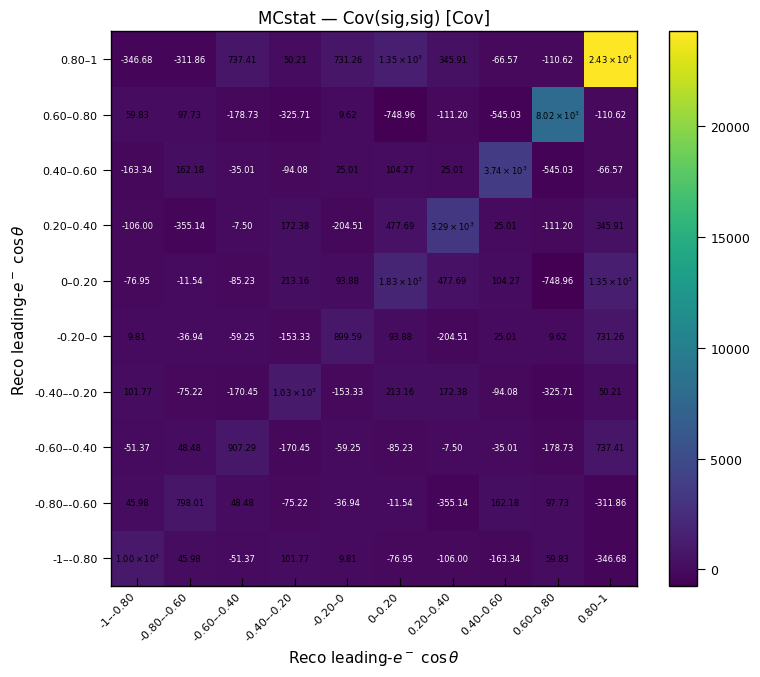

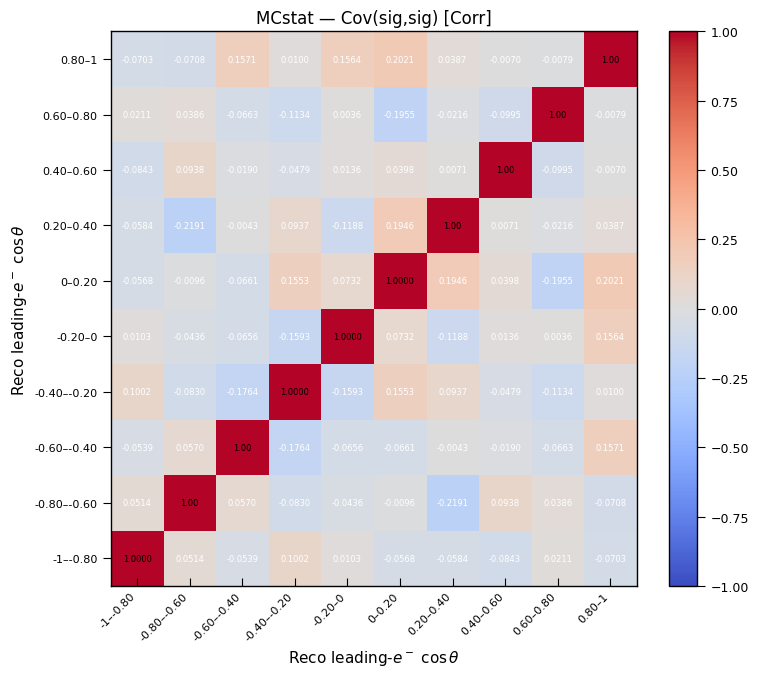

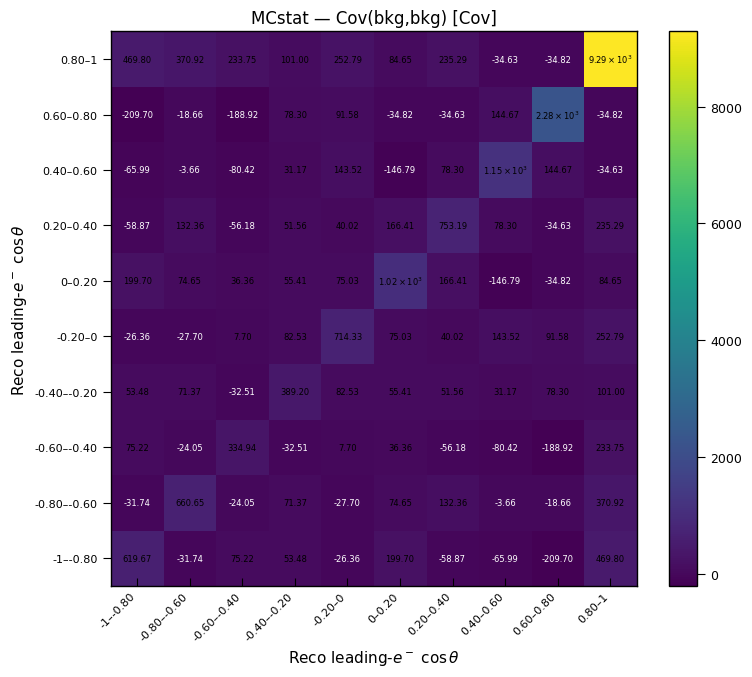

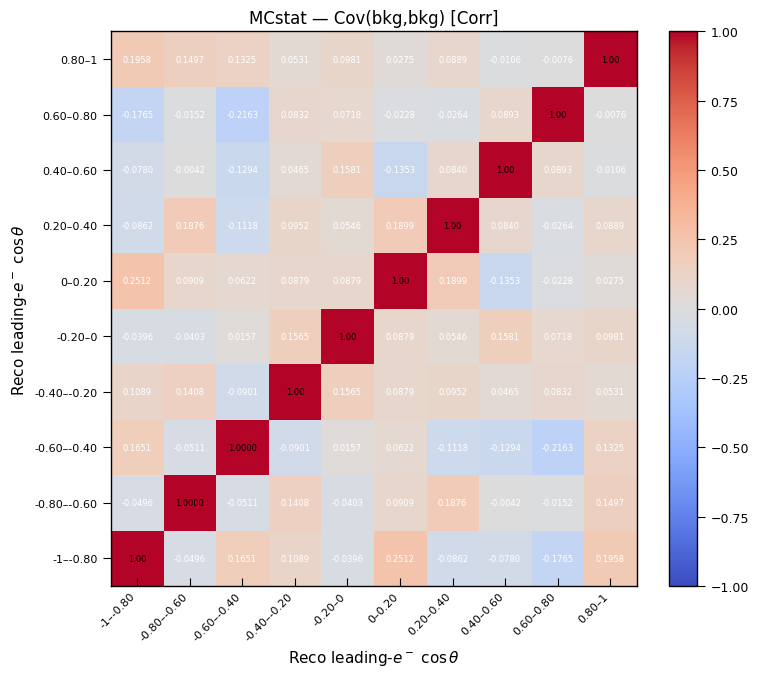

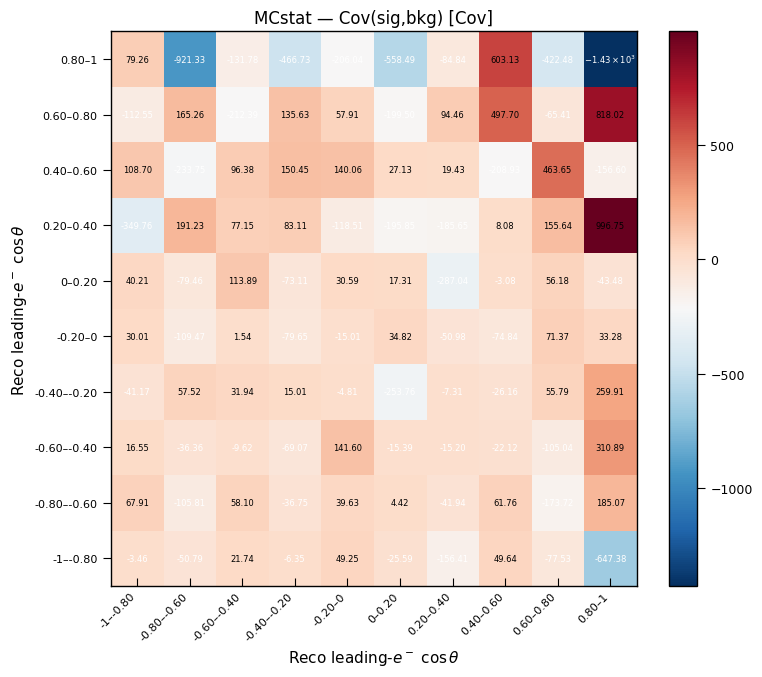

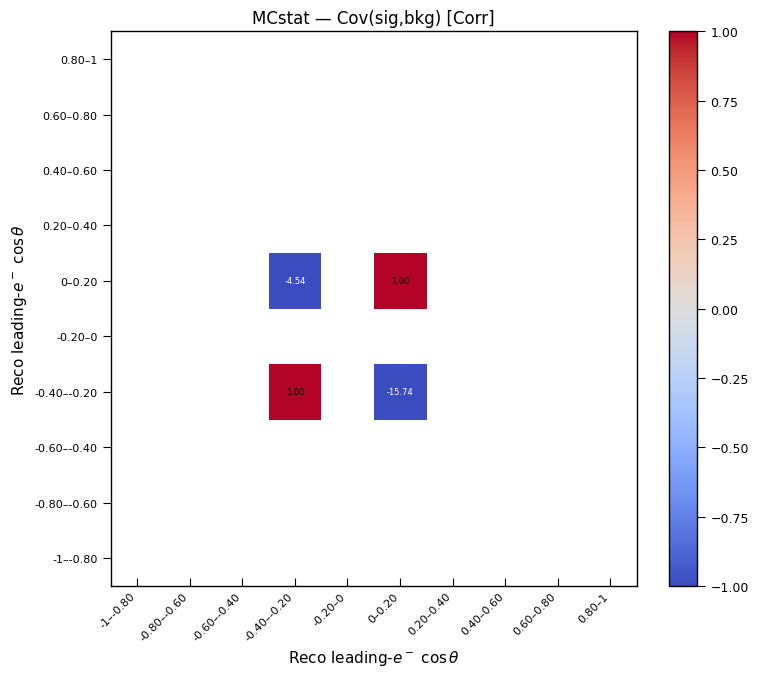

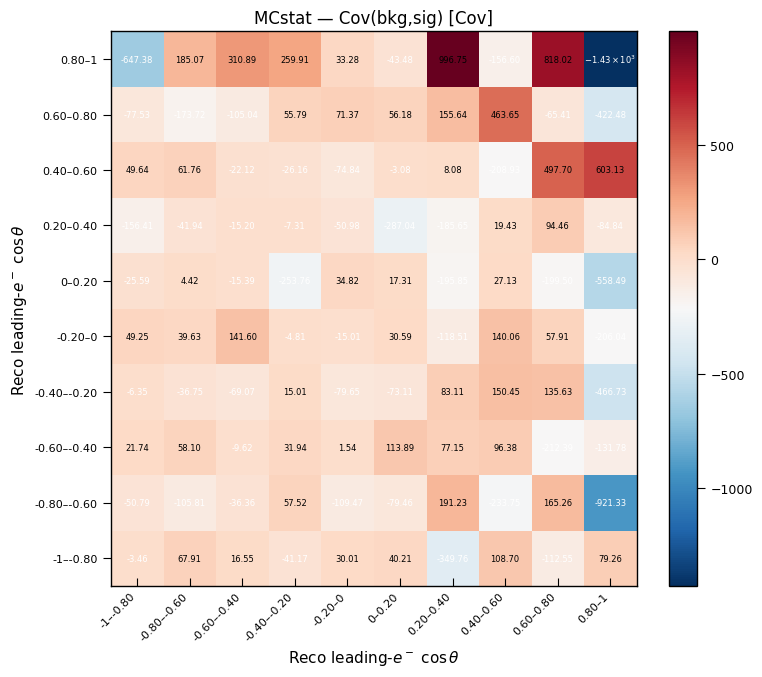

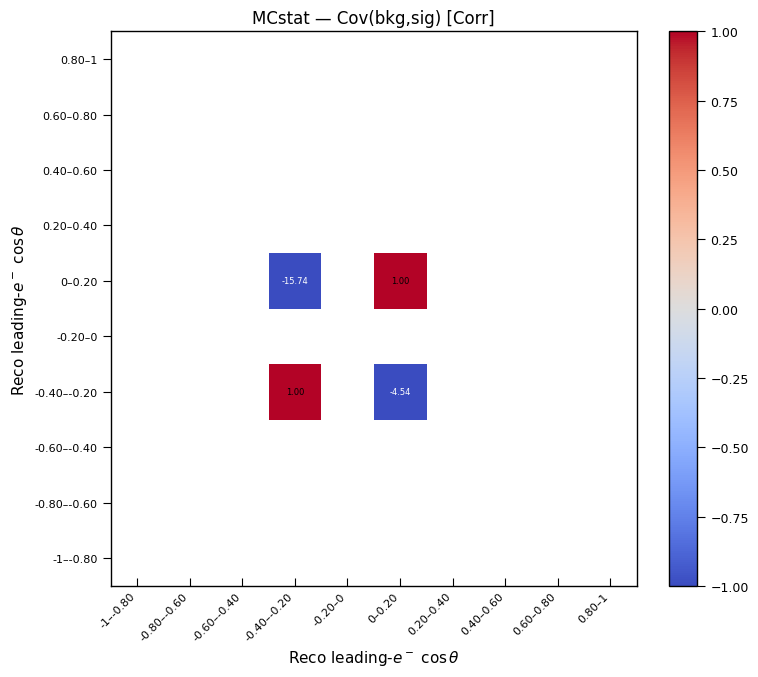

  [WARN] cov reco_costheta/pot/cov_ms_ms: 'pot'
  [WARN] cov reco_costheta/pot/cov_bs_bs: 'pot'
  [WARN] cov reco_costheta/pot/cov_ms_bs: 'pot'
  [WARN] cov reco_costheta/pot/cov_bs_ms: 'pot'
  [WARN] cov reco_costheta/ntargets/cov_ms_ms: 'ntargets'
  [WARN] cov reco_costheta/ntargets/cov_bs_bs: 'ntargets'
  [WARN] cov reco_costheta/ntargets/cov_ms_bs: 'ntargets'
  [WARN] cov reco_costheta/ntargets/cov_bs_ms: 'ntargets'
Heatmaps -> plots_syst/cov/


In [24]:
BLOCK_LABELS = {
    'cov_ms_ms': ('Cov(sig,sig)', 'viridis',  None,  None),
    'cov_bs_bs': ('Cov(bkg,bkg)', 'viridis',  None,  None),
    'cov_ms_bs': ('Cov(sig,bkg)', 'RdBu_r',   None,  None),
    'cov_bs_ms': ('Cov(bkg,sig)', 'RdBu_r',   None,  None),
}

for vcfg in VAR_CFGS:
    for src, covs in cov_results[vcfg.name].items():
        for bk, (bl, cmap, vmin, vmax) in BLOCK_LABELS.items():
            bv       = covs[bk]
            cov_mat  = _mat(bv)
            corr_mat = bv.get('corr', None) if isinstance(bv, dict) else None

            try:
                fig, _ = plot_heatmap_custom(
                    cov_mat, f'{SRC_LABEL[src]} — {bl} [Cov]',
                    vcfg, cmap=cmap, vmin=vmin, vmax=vmax)
                savefig(fig, f'{vcfg.name}_{src}_{bk}_cov', 'cov')
            except Exception as e:
                print(f'  [WARN] cov {vcfg.name}/{src}/{bk}: {e}')

            if corr_mat is not None:
                try:
                    fig, _ = plot_heatmap_custom(
                        corr_mat, f'{SRC_LABEL[src]} — {bl} [Corr]',
                        vcfg, cmap='coolwarm', vmin=-1, vmax=1)
                    savefig(fig, f'{vcfg.name}_{src}_{bk}_corr', 'cov')
                except Exception as e:
                    print(f'  [WARN] corr {vcfg.name}/{src}/{bk}: {e}')

print('Heatmaps -> plots_syst/cov/')

## 12. Plots: Fractional Uncertainties per Bin

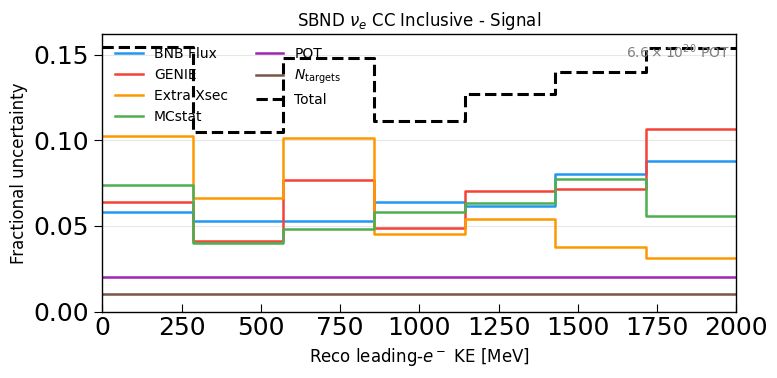

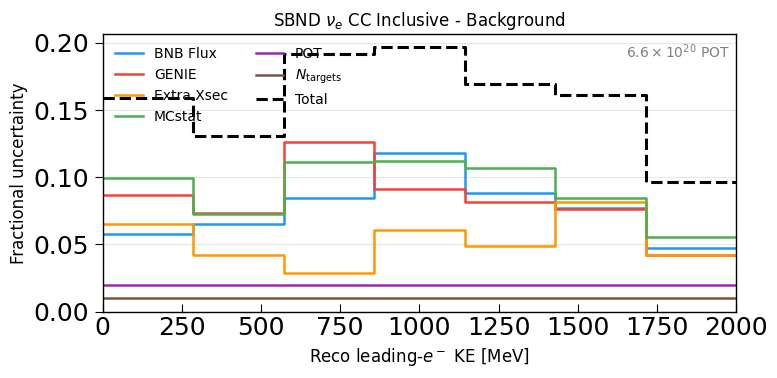

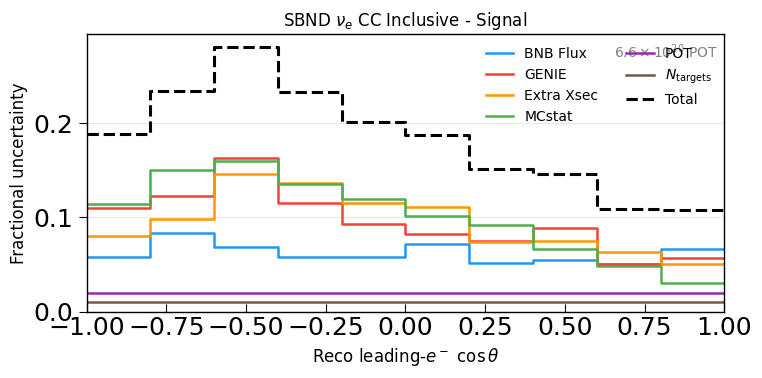

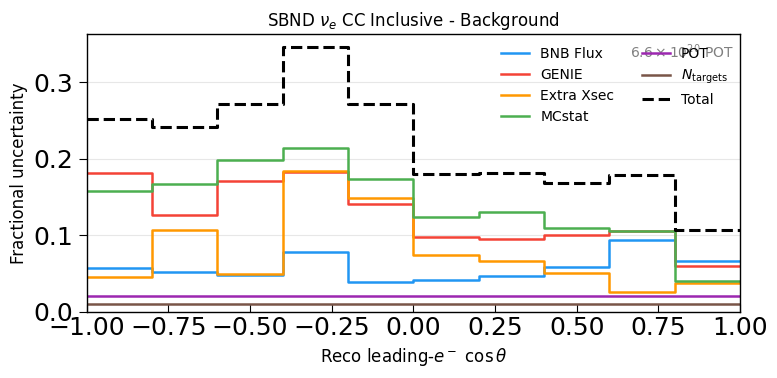

Fracunc plots -> plots_syst/fracunc/


In [25]:
SRC_LABEL = {
    'flux': 'BNB Flux', 'genie': 'GENIE', 'extra_xsec': 'Extra Xsec',
    'mcstat': 'MCstat', 'pot': 'POT', 'ntargets': r'$N_\mathrm{targets}$',
}
COLORS = {
    'flux': '#2196F3', 'genie': '#F44336', 'extra_xsec': '#FF9800',
    'mcstat': '#4CAF50', 'pot': '#9C27B0', 'ntargets': '#795548',
}
def plot_fracunc(vcfg, cv_arr, cov_results_var, block_key, categ):
    fig, ax = plt.subplots(figsize=(8, 4))
    total_var = np.zeros(len(vcfg.bin_centers))
    for src, covs in cov_results_var.items():
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            diag = np.diag(_mat(covs[block_key])).clip(0)
            frac = np.where(cv_arr > 0, np.sqrt(diag) / cv_arr, 0.0)
        xe = np.append(vcfg.bins[:-1], vcfg.bins[-1])
        ye = np.append(frac, frac[-1])
        ax.step(xe, ye, where='post', label=SRC_LABEL[src],
                color=COLORS.get(src, 'gray'), lw=1.8)
        total_var += diag
    tot = np.where(cv_arr > 0, np.sqrt(total_var) / cv_arr, 0.0)
    ax.step(np.append(vcfg.bins[:-1], vcfg.bins[-1]),
            np.append(tot, tot[-1]),
            where='post', label='Total', color='black', lw=2.2, ls='--')
    ax.set_xlabel(vcfg.var_plot_name, fontsize=12)
    ax.set_ylabel('Fractional uncertainty', fontsize=12)
    ax.set_title(f'{TITLE} - {categ}', fontsize=12)
    ax.legend(fontsize=10, ncol=2)
    ax.set_xlim(vcfg.bins[0], vcfg.bins[-1]); ax.set_ylim(bottom=0)
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.99, 0.97, vcfg.pot_label, transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color='gray')
    fig.tight_layout(); return fig

for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]; covs_var = cov_results[vcfg.name]
    for bk, categ, cv_arr in [
        ('cov_ms_ms', 'Signal',     cv['sig_cv']),
        ('cov_bs_bs', 'Background', cv['bkg_cv']),
    ]:
        fig = plot_fracunc(vcfg, cv_arr, covs_var, bk, categ)
        savefig(fig, f'{vcfg.name}_fracunc_{categ.lower()}', 'fracunc')
print('Fracunc plots -> plots_syst/fracunc/')


In [27]:
# After computing universe histograms, add chi2 for each source
import nue_helpers as nh
for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    for src, ud in univ_results[vcfg.name].items():
        if src in ('pot', 'ntargets'):
            continue  # no universes for flat systs
        # chi2 of each universe vs CV, take median
        chi2s = []
        for u in range(ud['sig'].shape[0]):
            c2, _, _ = nh.chi2_pvalue(ud['sig'][u], cv['sig_cv'])
            chi2s.append(c2)
        print(f"  [{vcfg.name}] {src}: median χ²/ndof = "
              f"{np.median(chi2s):.1f}/{len(cv['sig_cv'])}")

  [reco_ke] flux: median χ²/ndof = 16.0/7
  [reco_ke] genie: median χ²/ndof = 39.4/7
  [reco_ke] extra_xsec: median χ²/ndof = 46.5/7
  [reco_ke] mcstat: median χ²/ndof = 27.3/7
  [reco_costheta] flux: median χ²/ndof = 14.3/10
  [reco_costheta] genie: median χ²/ndof = 47.3/10
  [reco_costheta] extra_xsec: median χ²/ndof = 47.3/10
  [reco_costheta] mcstat: median χ²/ndof = 38.5/10


## 13. CV Stacked Histogram + Systematic Band

In [28]:
print(f"sel_topo shape        : {sel_topo.shape}")
print(f"Index names           : {sel_topo.index.names}")
print(f"Index nlevels         : {sel_topo.index.nlevels}")
stage_sum = sel_topo[FINAL_STAGE].sum()
sig_sum   = (sel_topo[FINAL_STAGE] & (sel_topo['truth_cat'] == 0)
             & sel_topo['reco_ke'].notna()).sum()
print(f"Passing {FINAL_STAGE}: {stage_sum}")
print(f"Signal passing stage  : {sig_sum}")
print(f"Expected weighted sig : {sig_sum * pot_scale:.1f}  (should be ~9322)")

sel_topo shape        : (980816, 16)
Index names           : ['__ntuple', 'entry', 'rec.dlp..index']
Index nlevels         : 3
Passing sel_vertex_distance: 3730
Signal passing stage  : 2305
Expected weighted sig : 10110.1  (should be ~9322)


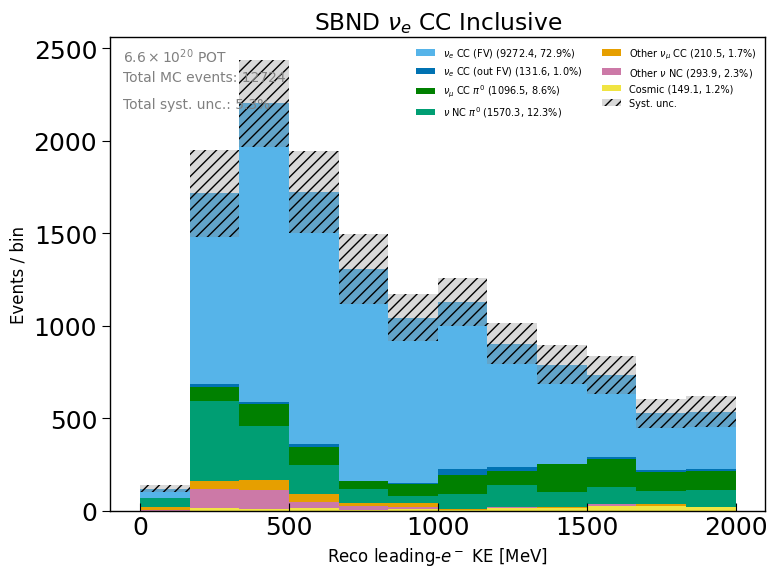

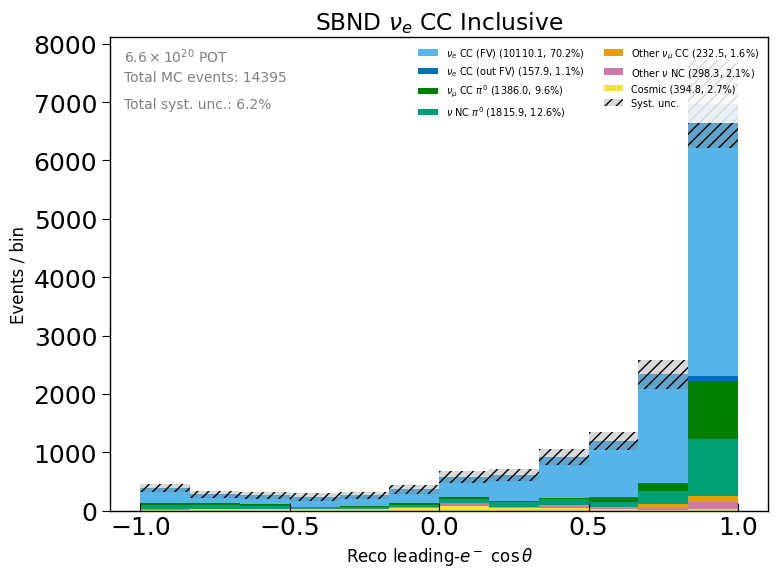

Stacked+syst -> plots_syst/


In [29]:
import nue_helpers as nh

DISPLAY_CATS  = [0, 1, 2, 3, 4, 5, 6]
FALLBACK_CLRS = ['#1f77b4','#aec7e8','#ff7f0e','#ffbb78','#2ca02c','#98df8a','#d62728']
FALLBACK_LBLS = [r'$\nu_e$ CC FV', r'$\nu_e$ CC out FV',
                 r'$\nu_\mu$ CC+$\pi^0$', r'NC $\pi^0$',
                 r'Other $\nu_\mu$ CC', 'Other NC', 'Cosmic']
_labels = [nh.CAT_LABELS[c] for c in DISPLAY_CATS] 
_colors = [nh.CAT_COLORS[c] for c in DISPLAY_CATS] 

# Use more bins for display (separate from covariance bins)
DISP_KE_BINS  = np.linspace(0, 2000, 13)   # 40 bins, 50 MeV wide
DISP_COS_BINS = np.linspace(-1, 1,   13)   # 40 bins

DISP_BINS = {'reco_ke': DISP_KE_BINS, 'reco_costheta': DISP_COS_BINS}

for vcfg in VAR_CFGS:
    cv       = cv_results[vcfg.name]
    covs_var = cov_results[vcfg.name]
    total_var = sum(np.diag(_mat(covs_var[s]['cov_ms_ms'])).clip(0) for s in covs_var)

    # Fractional unc from covariance bins → interpolate onto display bins
    cov_centers  = vcfg.bin_centers
    disp_bins    = DISP_BINS[vcfg.name]
    disp_centers = 0.5 * (disp_bins[:-1] + disp_bins[1:])
    frac_cv      = np.where(cv['sig_cv'] > 0,
                            np.sqrt(total_var.clip(0)) / cv['sig_cv'], 0.0)
    frac_disp    = np.interp(disp_centers, cov_centers, frac_cv)

    # ── Stacked histogram (nh handles weights & NaN correctly) ────────────
    def _cat(col, cat):
        m = (sel_topo[FINAL_STAGE]
             & (sel_topo['truth_cat'] == cat)
             & sel_topo['reco_ke'].notna()
             & sel_topo['reco_costheta'].notna())
        return sel_topo.loc[m, col].values   # NO clip — numpy excludes OOB naturally

    fig, ax = plt.subplots(figsize=(8, 6))
    nh.plot_stacked_hist(
        series_list=[_cat(vcfg.name, c) for c in DISPLAY_CATS],
        labels=_labels, colors=_colors,
        bins=disp_bins,
        weights=pot_scale,
        xlabel=vcfg.var_plot_name,
        title=TITLE,
        pot_label=POT_LABEL,
        ax=ax,
        invert_stack_order=True,
        show_counts=True,
        show_percentage=True,
    )

    # ── Syst uncertainty band (on total MC = sig+bkg) ─────────────────────
    # Recompute total MC per display bin for band baseline
    total_disp = np.zeros(len(disp_centers))
    for cat in DISPLAY_CATS:
        m = (sel_topo[FINAL_STAGE] & (sel_topo['truth_cat'] == cat)
             & sel_topo['reco_ke'].notna() & sel_topo['reco_costheta'].notna())
        v, _ = np.histogram(sel_topo.loc[m, vcfg.name].values,
                            bins=disp_bins,
                            weights=np.full(m.sum(), pot_scale))
        total_disp += v

    unc_disp = frac_disp * total_disp
    bw = np.diff(disp_bins)
    ax.bar(disp_bins[:-1], 2 * unc_disp, bottom=total_disp - unc_disp,
           width=bw, align='edge', alpha=0.3, color='gray',
           hatch='///', label='Syst. unc.', linewidth=0)

    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles, lbls, fontsize=7, ncol=2, loc='upper right',
              frameon=True, framealpha=0.85, edgecolor='none')
    total_frac = np.sqrt(total_var.sum()) / cv['sig_cv'].sum() if cv['sig_cv'].sum() > 0 else 0
    ax.text(0.02, 0.85, f'Total syst. unc.: {total_frac*100:.1f}%',
            transform=ax.transAxes, fontsize=10, color='gray')
    fig.tight_layout()
    savefig(fig, f'{vcfg.name}_cv_with_syst_band')

print('Stacked+syst -> plots_syst/')

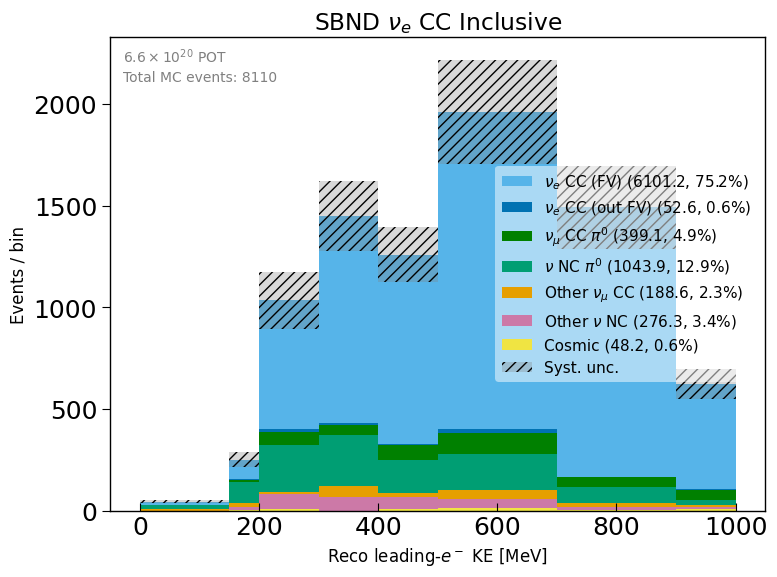

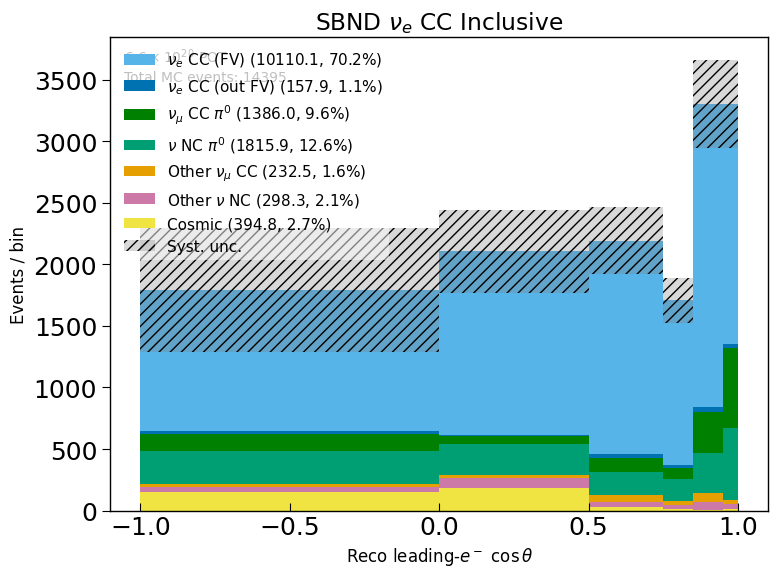

Stacked+syst (xsec bins) -> plots_syst/


In [30]:
from nue_xsec_helpers import make_nuecc_binning2d

binning2d = make_nuecc_binning2d()

_ke_edges  = np.unique(np.concatenate(binning2d.diff_momentum_bins_2d))
_ke_edges  = _ke_edges[_ke_edges <= 1000.0]          # clamp max to 1000 MeV
_cos_edges = binning2d.diff_costheta_bins.copy()
_cos_edges[-1] = 1.0

# Add reco_p with the same KE edges (MeV/c, same scale)
DISP_BINS = {
    'reco_ke':       _ke_edges,
    'reco_costheta': _cos_edges,
    'reco_p':        _ke_edges,
}

for vcfg in VAR_CFGS:
    if vcfg.name not in DISP_BINS:
        continue

    cv       = cv_results[vcfg.name]
    covs_var = cov_results[vcfg.name]
    total_var = sum(np.diag(_mat(covs_var[s]['cov_ms_ms'])).clip(0) for s in covs_var)

    cov_centers  = vcfg.bin_centers
    disp_bins    = DISP_BINS[vcfg.name]
    disp_centers = 0.5 * (disp_bins[:-1] + disp_bins[1:])
    frac_cv      = np.where(cv['sig_cv'] > 0,
                            np.sqrt(total_var.clip(0)) / cv['sig_cv'], 0.0)
    frac_disp    = np.interp(disp_centers, cov_centers, frac_cv)

    def _cat(col, cat):
        m = (sel_topo[FINAL_STAGE]
             & (sel_topo['truth_cat'] == cat)
             & sel_topo['reco_ke'].notna()
             & sel_topo['reco_costheta'].notna())
        return sel_topo.loc[m, col].values

    fig, ax = plt.subplots(figsize=(8, 6))
    nh.plot_stacked_hist(
        series_list=[_cat(vcfg.name, c) for c in DISPLAY_CATS],
        labels=_labels, colors=_colors,
        bins=disp_bins,
        weights=pot_scale,
        xlabel=vcfg.var_plot_name,
        title=TITLE,
        pot_label=POT_LABEL,
        ax=ax,
        invert_stack_order=True,
        show_counts=True,
        show_percentage=True,
    )

    total_disp = np.zeros(len(disp_centers))
    for cat in DISPLAY_CATS:
        m = (sel_topo[FINAL_STAGE] & (sel_topo['truth_cat'] == cat)
             & sel_topo['reco_ke'].notna() & sel_topo['reco_costheta'].notna())
        v, _ = np.histogram(sel_topo.loc[m, vcfg.name].values,
                            bins=disp_bins,
                            weights=np.full(m.sum(), pot_scale))
        total_disp += v

    unc_disp = frac_disp * total_disp
    bw = np.diff(disp_bins)
    ax.bar(disp_bins[:-1], 2 * unc_disp, bottom=total_disp - unc_disp,
           width=bw, align='edge', alpha=0.3, color='gray',
           hatch='///', label='Syst. unc.', linewidth=0)

    handles, lbls = ax.get_legend_handles_labels()
    ax.legend(handles, lbls, fontsize=11, ncol=1, loc='best',   # ← enlarged
              frameon=True, framealpha=0.5, edgecolor='none')
    fig.tight_layout()
    savefig(fig, f'{vcfg.name}_cv_with_syst_band_xsecbins')

print('Stacked+syst (xsec bins) -> plots_syst/')

n_costheta_bins  : 6
costheta_bins    : [-1.     0.     0.5    0.75   0.85   0.95   1.001]
KE bins (slice 0): [   0.  300.  700. 1200. 2000.] MeV
Saved -> ./plots_syst/nuecc_differential_costheta_slices.png


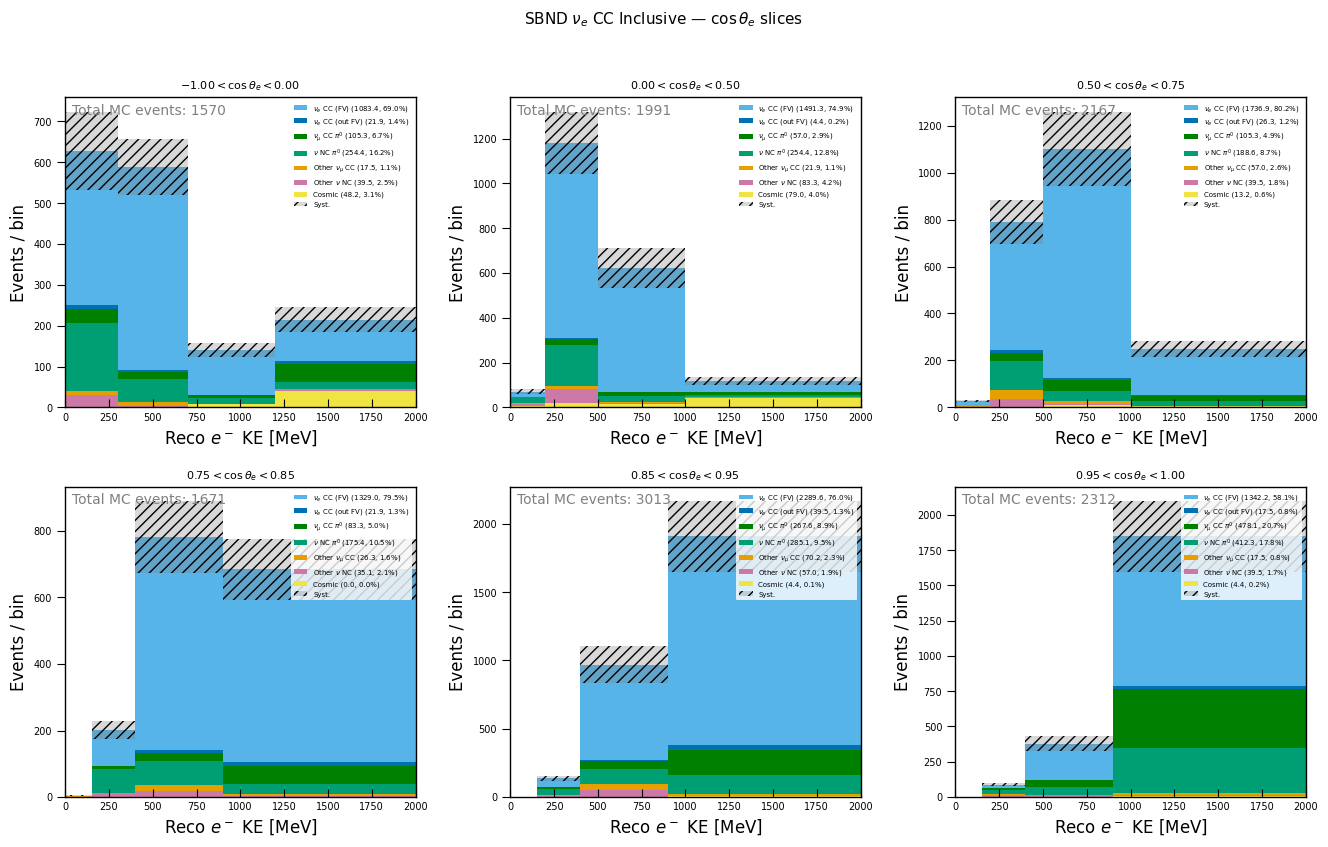

In [31]:
from nue_xsec_helpers import make_nuecc_binning2d, plot_nuecc_differential_stacked

binning2d_nue = make_nuecc_binning2d()
print(f'n_costheta_bins  : {binning2d_nue.n_costheta_bins}')
print(f'costheta_bins    : {binning2d_nue.diff_costheta_bins}')
print(f'KE bins (slice 0): {binning2d_nue.diff_momentum_bins_2d[0]} MeV')

cv_ke        = cv_results['reco_ke']
covs_ke      = cov_results['reco_ke']
total_var_ke = sum(np.diag(_mat(covs_ke[s]['cov_ms_ms'])).clip(0) for s in covs_ke)
frac_unc_ke  = np.where(cv_ke['sig_cv'] > 0,
                        np.sqrt(total_var_ke) / cv_ke['sig_cv'], 0.0)

fig, axs = plot_nuecc_differential_stacked(
    sel_df               = sel_topo,
    stage_col            = FINAL_STAGE,
    ke_col               = 'reco_ke',
    costheta_col         = 'reco_costheta',
    truth_cat_col        = 'truth_cat',
    binning2d            = binning2d_nue,
    display_cats         = DISPLAY_CATS,
    labels               = _labels,
    colors               = _colors,
    pot_scale            = pot_scale,
    frac_unc_ke          = frac_unc_ke,
    reco_ke_bins         = VAR_CFGS[0].bins,
    title                = fr'{TITLE} — $\cos\theta_e$ slices',
    pot_label            = POT_LABEL,
    plot_dir             = PLOT_DIR,
    filename             = 'nuecc_differential_costheta_slices',
    plot_stacked_hist_fn = nh.plot_stacked_hist,
)

In [32]:

print(f'\n{"="*68}')
print(f'{"Variable":<16} {"Source":<10} {"Category":<14} {"Mean frac. unc.":>16}')
print(f'{"="*68}')
for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    for src, covs in cov_results[vcfg.name].items():
        for bk, categ, cv_arr in [
            ('cov_ms_ms', 'Signal',     cv['sig_cv']),
            ('cov_bs_bs', 'Background', cv['bkg_cv']),
        ]:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                frac = np.where(cv_arr > 0,
                    np.sqrt(np.diag(_mat(covs[bk])).clip(0)) / cv_arr, np.nan)
            fu = float(np.nanmean(frac))
            print(f'  {vcfg.name:<14} {src:<10} {categ:<14} {fu*100:>14.2f}%')
print(f'{"="*68}')
print(f'\nNPZ files -> {SYST_DIR}/')
for vcfg in VAR_CFGS:
    vd = f'{SYST_DIR}/{vcfg.name}'
    if os.path.isdir(vd):
        print(f'  {vcfg.name}: {os.listdir(vd)}')
print(f'Plots     -> {PLOT_DIR}/')
for sub in ['univ', 'cov', 'fracunc']:
    sd = f'{PLOT_DIR}/{sub}'
    if os.path.isdir(sd):
        print(f'  {sub}/: {len(os.listdir(sd))} files')



Variable         Source     Category        Mean frac. unc.
  reco_ke        flux       Signal                   6.56%
  reco_ke        flux       Background               7.68%
  reco_ke        genie      Signal                   6.85%
  reco_ke        genie      Background               8.23%
  reco_ke        extra_xsec Signal                   6.26%
  reco_ke        extra_xsec Background               5.28%
  reco_ke        mcstat     Signal                   5.95%
  reco_ke        mcstat     Background               9.16%
  reco_ke        pot        Signal                   2.00%
  reco_ke        pot        Background               2.00%
  reco_ke        ntargets   Signal                   1.00%
  reco_ke        ntargets   Background               1.00%
  reco_costheta  flux       Signal                   6.21%
  reco_costheta  flux       Background               5.79%
  reco_costheta  genie      Signal                   9.59%
  reco_costheta  genie      Background              12

In [33]:
# # Check what fraction of weights are NaN in wgt_aligned
# nan_frac = wgt_aligned[bnb_cols_aligned].isna().mean().mean()
# print(f'NaN fraction in BNB weights: {nan_frac:.1%}')

# # Check a few weight values for matched rows
# matched = wgt_aligned[bnb_cols_aligned[0]].notna()
# print(f'Matched interactions: {matched.sum()} / {len(matched)}')
# print(wgt_aligned.loc[matched, bnb_cols_aligned[:3]].describe())

In [34]:
for vcfg in VAR_CFGS:
    cv = cv_results[vcfg.name]
    scale = pot_scale  # your pot_scale from the selection notebook
    print(f"\n{vcfg.name} — estimated raw MC events per bin:")
    print(f"  signal : {np.round(cv['sig_cv'] / scale, 1)}")
    print(f"  bkg    : {np.round(cv['bkg_cv'] / scale, 1)}")


reco_ke — estimated raw MC events per bin:
  signal : [142. 613. 462. 350. 254. 173. 311.]
  bkg    : [121. 227.  78.  76.  96. 101. 278.]

reco_costheta — estimated raw MC events per bin:
  signal : [  63.   43.   43.   54.   57.   96.  142.  211.  425. 1171.]
  bkg    : [ 36.  35.  21.  21.  35.  59.  48.  71. 103. 548.]


## Unfolding with Omnifold 

In [35]:
# ── Export per-bin efficiency + flux/targets for OmniFold xsec ────────────────
import numpy as np, os

OMNIFOLD_OUT = '/home/castalyf/Omnifold_SBND/sbnd/exported_weights/'
os.makedirs(OMNIFOLD_OUT, exist_ok=True)

RECO_VARS   = ['reco_ke', 'reco_costheta', 'reco_p']
FINAL_STAGE = 'sel_vertex_distance'

sig_all = sel_topo[sel_topo['is_sig']]
sig_sel = sel_topo[sel_topo['is_sig'] & sel_topo[FINAL_STAGE]].copy()
reco_raw = sig_sel[RECO_VARS].values.astype(np.float32)
sig_sel_valid = sig_sel[~np.isnan(reco_raw).any(axis=1)]

bins_ke  = np.array([0, 200, 400, 600, 800, 1000, 1400, 2000])
bins_cos = np.linspace(-1, 1, 11)

for var, bins, label in [('true_ke', bins_ke, 'true_ke'),
                          ('true_costheta', bins_cos, 'true_costheta')]:
    N_all, _ = np.histogram(sig_all[var].dropna(), bins=bins)
    N_sel, _ = np.histogram(sig_sel_valid[var].dropna(), bins=bins)
    eff = N_sel / N_all.clip(1)
    np.save(OMNIFOLD_OUT + f'efficiency_{label}.npy', eff)
    centers = 0.5 * (bins[:-1] + bins[1:])
    print(f"\n{label} efficiency:")
    for c, e, na, ns in zip(centers, eff, N_all, N_sel):
        print(f"  {c:8.1f}: {e:.4f}  ({ns}/{na})")

# Save pot_scale and N_targets for cross-section normalization
pot_scale = float(sel_topo['pot_scale'].iloc[0])
np.save(OMNIFOLD_OUT + 'pot_scale.npy', np.array([pot_scale]))
print(f"\npot_scale: {pot_scale}")
print("Saved efficiency and normalization files.")


true_ke efficiency:
     100.0: 0.0730  (23/315)
     300.0: 0.4598  (343/746)
     500.0: 0.5716  (387/677)
     700.0: 0.6000  (318/530)
     900.0: 0.7018  (273/389)
    1200.0: 0.7816  (408/522)
    1700.0: 0.8050  (322/400)

true_costheta efficiency:
      -0.9: 0.3030  (20/66)
      -0.7: 0.3647  (31/85)
      -0.5: 0.2810  (34/121)
      -0.3: 0.3388  (41/121)
      -0.1: 0.4167  (60/144)
       0.1: 0.4889  (88/180)
       0.3: 0.4601  (127/276)
       0.5: 0.5381  (219/407)
       0.7: 0.6241  (420/673)
       0.9: 0.7179  (1265/1762)

pot_scale: 4.386173725128174
Saved efficiency and normalization files.
